In [ ]:
# D
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# D
%cd /content/drive/MyDrive/NN_RESEARCH/

/content/drive/MyDrive/NN_RESEARCH


In [ ]:
#D
!git clone https://github.com/imics-lab/biodiffusion.git

In [ ]:
#D
!rm -rf biodiffusion
!git clone https://github.com/imics-lab/biodiffusion.git


In [ ]:
#D
%cd biodiffusion

/content/drive/.shortcut-targets-by-id/1u6aArvTMPuwQhmL0dFEB_C0Cf_lO_JVi/NN_RESEARCH/biodiffusion


In [ ]:
#D
!ls

In [ ]:
#D
!pip install torch torchvision


In [ ]:
#D
%cd /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src

DDPM.py


In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py

# Import necessary libraries
import os
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from tqdm import tqdm
from types import SimpleNamespace
from torch import optim
from utils import *
from modules.modules import UNet
import wandb
import argparse
import logging
from torch.utils.tensorboard import SummaryWriter



# Set up logging
logging.basicConfig(format="%(asctime)s - %(levelname)s: %(message)s", level=logging.INFO, datefmt="%I:%M:%S")

# Define configuration using SimpleNamespace
config = SimpleNamespace(
    run_name="DDPM_Unconditional",
    epochs=100,
    batch_size=12,
    seed=43,
    slice_size=1,
    num_classes=10,
    img_size=32,
    dataset_path=get_cifar(img_size=32),
    train_folder="train",
    val_folder="test",
    num_workers=10,
    device="cuda:2",
    lr=3e-4,
    noise_steps=1000
)

# Define the Diffusion class
class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=256, device="cuda"):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.img_size = img_size
        self.device = device

        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def prepare_noise_schedule(self):
        return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        Ɛ = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * Ɛ, Ɛ

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,))

    def sample(self, model, n):
        logging.info(f"Sampling {n} new images....")
        model.eval()
        with torch.no_grad():
            x = torch.randn((n, 3, self.img_size, self.img_size)).to(self.device)
            for i in tqdm(reversed(range(1, self.noise_steps)), position=0):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t)
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                if i > 1:
                    noise = torch.randn_like(x)
                else:
                    noise = torch.zeros_like(x)
                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        x = (x * 255).type(torch.uint8)
        return x

def train(args):
    # Safe device detection
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    args.device = device  # update args in case other code uses it

    train_dataloader, val_dataloader = get_data(args)

    model = UNet(c_in=3, c_out=3).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=args.lr)
    mse = nn.MSELoss()
    diffusion = Diffusion(img_size=args.img_size, device=device)
    logger = SummaryWriter(os.path.join("runs", args.run_name))
    l = len(train_dataloader)

    checkpoint_dir = os.path.join("./results", "checkpoints")
    loss_curve_dir = os.path.join("./results", "loss_curve")
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(loss_curve_dir, exist_ok=True)

    losses = []

    for epoch in range(args.epochs):
        logging.info(f"Starting epoch {epoch + 1}/{args.epochs}")
        pbar = tqdm(train_dataloader)
        running_loss = 0

        for i, (images, _) in enumerate(pbar):
            images = images.to(device)
            t = diffusion.sample_timesteps(images.shape[0]).to(device)
            x_t, noise = diffusion.noise_images(images, t)
            predicted_noise = model(x_t, t)
            loss = mse(noise, predicted_noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(MSE=loss.item())
            logger.add_scalar("MSE", loss.item(), global_step=epoch * l + i)

        epoch_loss = running_loss / len(train_dataloader)
        losses.append(epoch_loss)
        logging.info(f"Epoch [{epoch+1}/{args.epochs}] Loss: {epoch_loss:.4f}")

        # Save checkpoint
        ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch+1}.pt")
        torch.save(model.state_dict(), ckpt_path)

    # Save loss curve
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, args.epochs + 1), losses, marker='o', label="Training Loss")
    plt.title("DDPM Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(loss_curve_dir, "loss_curve.png"))
    plt.close()

    logging.info("Training is complete. Checkpoints and loss curve are saved in ./results/")


# Define the argument parser
def parse_args(config):
    parser = argparse.ArgumentParser(description='Process hyper-parameters')
    parser.add_argument('--run_name', type=str, default=config.run_name, help='name of the run')
    parser.add_argument('--epochs', type=int, default=config.epochs, help='number of epochs')
    parser.add_argument('--seed', type=int, default=config.seed, help='random seed')
    parser.add_argument('--batch_size', type=int, default=config.batch_size, help='batch size')
    parser.add_argument('--img_size', type=int, default=config.img_size, help='image size')
    parser.add_argument('--num_classes', type=int, default=config.num_classes, help='number of classes')
    parser.add_argument('--dataset_path', type=str, default=config.dataset_path, help='path to dataset')
    parser.add_argument('--device', type=str, default=config.device, help='device')
    parser.add_argument('--lr', type=float, default=config.lr, help='learning rate')
    parser.add_argument('--slice_size', type=int, default=config.slice_size, help='slice size')
    parser.add_argument('--noise_steps', type=int, default=config.noise_steps, help='noise steps')
    args = vars(parser.parse_args())

    for k, v in args.items():
        setattr(config, k, v)

# Define the launch function
def launch():
    parse_args(config)
    train(config)

# Execute the script
if __name__ == '__main__':
    launch()


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/utils.py


In [ ]:
!ls "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/src"


In [ ]:
from google.colab import files
files.upload()


In [ ]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json


In [ ]:
#D
!python ddpm.py

In [ ]:
%%writefile  /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/utils.py

import os, random
from pathlib import Path
from kaggle import api
import torch
import torchvision
import torchvision.transforms as T
import numpy as np
from PIL import Image
from fastdownload import FastDownload
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import fastprogress
fastprogress.fastprogress.NO_BAR = True

cifar_labels = "airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck".split(",")
alphabet_labels = "A B C D E F G H I J K L M N O P Q R S T U V W X Y Z".split(" ")


def set_seed(s, reproducible=False):
    "Set random seed for random, torch, and numpy (where available)"
    try: torch.manual_seed(s)
    except NameError: pass
    try: torch.cuda.manual_seed_all(s)
    except NameError: pass
    try: np.random.seed(s%(2**32-1))
    except NameError: pass
    random.seed(s)
    if reproducible:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def untar_data(url, force_download=False, base='./datasets'):
    d = FastDownload(base=base)
    return d.get(url, force=force_download, extract_key='data')


def get_alphabet(args):
    get_kaggle_dataset("alphabet", "thomasqazwsxedc/alphabet-characters-fonts-dataset")
    train_transforms = T.Compose([
        T.Grayscale(),
        T.ToTensor(),])
    train_dataset = torchvision.datasets.ImageFolder(root="./alphabet/Images/Images/", transform=train_transforms)
    if args.slice_size>1:
        train_dataset = torch.utils.data.Subset(train_dataset, indices=range(0, len(train_dataset), args.slice_size))
    train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers)
    return train_dataloader, None

def get_cifar(cifar100=False, img_size=32):
    """Safely load CIFAR-10 or CIFAR-100 using torchvision (no tar downloads)."""
    import torchvision.transforms as T
    data_dir = "./datasets/cifar"
    os.makedirs(data_dir, exist_ok=True)

    transform = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize((0.5,), (0.5,))
    ])

    if cifar100:
        torchvision.datasets.CIFAR100(root=data_dir, train=True, download=True, transform=transform)
        torchvision.datasets.CIFAR100(root=data_dir, train=False, download=True, transform=transform)
    else:
        torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)
        torchvision.datasets.CIFAR10(root=data_dir, train=False, download=True, transform=transform)

    return data_dir



def get_kaggle_dataset(dataset_path, # Local path to download dataset to
                dataset_slug, # Dataset slug (ie "zillow/zecon")
                unzip=True, # Should it unzip after downloading?
                force=False # Should it overwrite or error if dataset_path exists?
               ):
    '''Downloads an existing dataset and metadata from kaggle'''
    if not force and Path(dataset_path).exists():
        return Path(dataset_path)
    api.dataset_metadata(dataset_slug, str(dataset_path))
    api.dataset_download_files(dataset_slug, str(dataset_path))
    if unzip:
        zipped_file = Path(dataset_path)/f"{dataset_slug.split('/')[-1]}.zip"
        import zipfile
        with zipfile.ZipFile(zipped_file, 'r') as zip_ref:
            zip_ref.extractall(Path(dataset_path))
        zipped_file.unlink()

def one_batch(dl):
    return next(iter(dl))


def plot_images(images):
    plt.figure(figsize=(32, 32))
    plt.imshow(torch.cat([
        torch.cat([i for i in images.cpu()], dim=-1),
    ], dim=-2).permute(1, 2, 0).cpu())
    plt.show()


def save_images(images, path, **kwargs):
    grid = torchvision.utils.make_grid(images, **kwargs)
    ndarr = grid.permute(1, 2, 0).to('cpu').numpy()
    im = Image.fromarray(ndarr)
    im.save(path)


def get_data(args):
    import torchvision
    import torchvision.transforms as T

    transform = T.Compose([
        T.Resize((args.img_size, args.img_size)),
        T.ToTensor(),
        T.Normalize((0.5,), (0.5,))
    ])

    # Directly load CIFAR datasets
    train_dataset = torchvision.datasets.CIFAR10(root=args.dataset_path, train=True, download=True, transform=transform)
    val_dataset = torchvision.datasets.CIFAR10(root=args.dataset_path, train=False, download=True, transform=transform)

    train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, num_workers=args.num_workers)
    val_dataloader = DataLoader(val_dataset, batch_size=args.batch_size * 2, shuffle=False, num_workers=args.num_workers)

    return train_dataloader, val_dataloader



def mk_folders(run_name):
    os.makedirs("models", exist_ok=True)
    os.makedirs("results", exist_ok=True)
    os.makedirs(os.path.join("models", run_name), exist_ok=True)
    os.makedirs(os.path.join("results", run_name), exist_ok=True)


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/utils.py


In [ ]:
!python3 "/content/drive/.shortcut-targets-by-id/1u6aArvTMPuwQhmL0dFEB_C0Cf_lO_JVi/NN_RESEARCH/biodiffusion/src/ddpm.py"



2025-11-08 19:53:45.378344: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762631625.398894    3916 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762631625.404987    3916 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762631625.420049    3916 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762631625.420073    3916 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762631625.420077    3916 computation_placer.cc:177] computation placer alr

In [ ]:
from google.colab import files
files.upload()


Saving kaggle (2).json to kaggle (2).json


{'kaggle (2).json': b'{"username":"khushdeep058","key":"07dfa1368427a3eb2200fb51837e0fd1"}'}

In [ ]:
!mkdir -p ~/.config/kaggle
!mv "kaggle (2).json" ~/.config/kaggle/kaggle.json
!chmod 600 ~/.config/kaggle/kaggle.json




In [ ]:
!ls /content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints

epoch_10.pt  epoch_1.pt   epoch_29.pt  epoch_38.pt  epoch_47.pt  epoch_56.pt
epoch_11.pt  epoch_20.pt  epoch_2.pt   epoch_39.pt  epoch_48.pt  epoch_57.pt
epoch_12.pt  epoch_21.pt  epoch_30.pt  epoch_3.pt   epoch_49.pt  epoch_58.pt
epoch_13.pt  epoch_22.pt  epoch_31.pt  epoch_40.pt  epoch_4.pt	 epoch_59.pt
epoch_14.pt  epoch_23.pt  epoch_32.pt  epoch_41.pt  epoch_50.pt  epoch_5.pt
epoch_15.pt  epoch_24.pt  epoch_33.pt  epoch_42.pt  epoch_51.pt  epoch_6.pt
epoch_16.pt  epoch_25.pt  epoch_34.pt  epoch_43.pt  epoch_52.pt  epoch_7.pt
epoch_17.pt  epoch_26.pt  epoch_35.pt  epoch_44.pt  epoch_53.pt  epoch_8.pt
epoch_18.pt  epoch_27.pt  epoch_36.pt  epoch_45.pt  epoch_54.pt  epoch_9.pt
epoch_19.pt  epoch_28.pt  epoch_37.pt  epoch_46.pt  epoch_55.pt


In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py

# Import necessary libraries
import os
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from tqdm import tqdm
from types import SimpleNamespace
from torch import optim
from utils import *
from modules.modules import UNet
import wandb
import argparse
import logging
from torch.utils.tensorboard import SummaryWriter

# Set up logging
logging.basicConfig(format="%(asctime)s - %(levelname)s: %(message)s", level=logging.INFO, datefmt="%I:%M:%S")

# Define configuration using SimpleNamespace
config = SimpleNamespace(
    run_name="DDPM_Unconditional",
    epochs=100,
    batch_size=12,
    seed=43,
    slice_size=1,
    num_classes=10,
    img_size=32,
    dataset_path=get_cifar(img_size=32),
    train_folder="train",
    val_folder="test",
    num_workers=10,
    device="cuda:2",
    lr=3e-4,
    noise_steps=1000
)

# Define the Diffusion class
class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=256, device="cuda"):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.img_size = img_size
        self.device = device

        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def prepare_noise_schedule(self):
        return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        Ɛ = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * Ɛ, Ɛ

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,))

    def sample(self, model, n):
        logging.info(f"Sampling {n} new images....")
        model.eval()
        with torch.no_grad():
            x = torch.randn((n, 3, self.img_size, self.img_size)).to(self.device)
            for i in tqdm(reversed(range(1, self.noise_steps)), position=0):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t)
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                if i > 1:
                    noise = torch.randn_like(x)
                else:
                    noise = torch.zeros_like(x)
                x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / (torch.sqrt(1 - alpha_hat))) * predicted_noise) + torch.sqrt(beta) * noise
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        x = (x * 255).type(torch.uint8)
        return x

# Training function with checkpoint resume
def train(args, checkpoint_path=None):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    args.device = device

    train_dataloader, val_dataloader = get_data(args)

    model = UNet(c_in=3, c_out=3).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=args.lr)
    mse = nn.MSELoss()
    diffusion = Diffusion(img_size=args.img_size, device=device)
    logger = SummaryWriter(os.path.join("runs", args.run_name))
    l = len(train_dataloader)

    checkpoint_dir = os.path.join("./results", "checkpoints")
    loss_curve_dir = os.path.join("./results", "loss_curve")
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(loss_curve_dir, exist_ok=True)

    losses = []
    start_epoch = 0

    # Load checkpoint if provided
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming training from epoch {start_epoch}")

    # Training loop
    for epoch in range(start_epoch, args.epochs):
        logging.info(f"Starting epoch {epoch + 1}/{args.epochs}")
        pbar = tqdm(train_dataloader)
        running_loss = 0

        for i, (images, _) in enumerate(pbar):
            images = images.to(device)
            t = diffusion.sample_timesteps(images.shape[0]).to(device)
            x_t, noise = diffusion.noise_images(images, t)
            predicted_noise = model(x_t, t)
            loss = mse(noise, predicted_noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(MSE=loss.item())
            logger.add_scalar("MSE", loss.item(), global_step=epoch * l + i)

        epoch_loss = running_loss / len(train_dataloader)
        losses.append(epoch_loss)
        logging.info(f"Epoch [{epoch+1}/{args.epochs}] Loss: {epoch_loss:.4f}")

        # Save checkpoint
        ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch+1}.pt")
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
        }, ckpt_path)

    # Save loss curve
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, args.epochs + 1), losses, marker='o', label="Training Loss")
    plt.title("DDPM Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(loss_curve_dir, "loss_curve.png"))
    plt.close()

    logging.info("Training is complete. Checkpoints and loss curve are saved in ./results/")

# Argument parser
def parse_args(config):
    parser = argparse.ArgumentParser(description='Process hyper-parameters')
    parser.add_argument('--run_name', type=str, default=config.run_name, help='name of the run')
    parser.add_argument('--epochs', type=int, default=config.epochs, help='number of epochs')
    parser.add_argument('--seed', type=int, default=config.seed, help='random seed')
    parser.add_argument('--batch_size', type=int, default=config.batch_size, help='batch size')
    parser.add_argument('--img_size', type=int, default=config.img_size, help='image size')
    parser.add_argument('--num_classes', type=int, default=config.num_classes, help='number of classes')
    parser.add_argument('--dataset_path', type=str, default=config.dataset_path, help='path to dataset')
    parser.add_argument('--device', type=str, default=config.device, help='device')
    parser.add_argument('--lr', type=float, default=config.lr, help='learning rate')
    parser.add_argument('--slice_size', type=int, default=config.slice_size, help='slice size')
    parser.add_argument('--noise_steps', type=int, default=config.noise_steps, help='noise steps')
    args = vars(parser.parse_args())

    for k, v in args.items():
        setattr(config, k, v)

# Launch function with checkpoint
def launch():
    parse_args(config)
    # Resume from a checkpoint (or set to None to start fresh)
    checkpoint_path = "content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints/epoch_59.pt"
    train(config, checkpoint_path=checkpoint_path)

# Execute the script
if __name__ == '__main__':
    launch()


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py


In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = 'khushdeep058'
os.environ['KAGGLE_KEY'] = '07dfa1368427a3eb2200fb51837e0fd1'


In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py

# ============================================================
# DDPM Training Script with Automatic Checkpoint Resume
# ============================================================

import os
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from tqdm import tqdm
from types import SimpleNamespace
from torch import optim
from utils import *
from modules.modules import UNet
import argparse
import logging
from torch.utils.tensorboard import SummaryWriter

# ------------------------------------------------------------
# Logging Setup
# ------------------------------------------------------------
logging.basicConfig(format="%(asctime)s - %(levelname)s: %(message)s", level=logging.INFO, datefmt="%I:%M:%S")

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
config = SimpleNamespace(
    run_name="DDPM_Unconditional",
    epochs=100,
    batch_size=12,
    seed=43,
    slice_size=1,
    num_classes=10,
    img_size=32,
    dataset_path=get_cifar(img_size=32),
    train_folder="train",
    val_folder="test",
    num_workers=10,
    device="cuda:0",
    lr=3e-4,
    noise_steps=1000
)

# ------------------------------------------------------------
# Diffusion Class
# ------------------------------------------------------------
class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=256, device="cuda"):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.img_size = img_size
        self.device = device

        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def prepare_noise_schedule(self):
        return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        eps = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * eps, eps

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,))

    def sample(self, model, n):
        logging.info(f"Sampling {n} new images....")
        model.eval()
        with torch.no_grad():
            x = torch.randn((n, 3, self.img_size, self.img_size)).to(self.device)
            for i in tqdm(reversed(range(1, self.noise_steps)), position=0):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t)
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                noise = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
                x = 1 / torch.sqrt(alpha) * (
                    x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * predicted_noise
                ) + torch.sqrt(beta) * noise
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        x = (x * 255).type(torch.uint8)
        return x

# ------------------------------------------------------------
# Utility: Find Latest Checkpoint
# ------------------------------------------------------------
def find_latest_checkpoint(checkpoint_dir):
    """Finds the latest checkpoint file in the directory."""
    if not os.path.exists(checkpoint_dir):
        return None
    checkpoints = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pt")]
    if not checkpoints:
        return None
    checkpoints = sorted(checkpoints, key=lambda x: int(x.split("_")[1].split(".")[0]))
    latest = checkpoints[-1]
    return os.path.join(checkpoint_dir, latest)

# ------------------------------------------------------------
# Training Function
# ------------------------------------------------------------
def train(args, checkpoint_path=None):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    args.device = device

    train_dataloader, val_dataloader = get_data(args)

    model = UNet(c_in=3, c_out=3).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=args.lr)
    mse = nn.MSELoss()
    diffusion = Diffusion(img_size=args.img_size, device=device)
    logger = SummaryWriter(os.path.join("runs", args.run_name))

    checkpoint_dir = os.path.join("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results", "checkpoints")
    loss_curve_dir = os.path.join("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results", "loss_curve")
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(loss_curve_dir, exist_ok=True)

    losses = []
    start_epoch = 0

    # --------------------------------------------------------
    # ✅ Automatically Resume from Latest Checkpoint
    # --------------------------------------------------------
    if checkpoint_path is None:
        checkpoint_path = find_latest_checkpoint(checkpoint_dir)

    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        start_epoch = checkpoint["epoch"] + 1
        print(f"✅ Resuming training from epoch {start_epoch} ({checkpoint_path})")
    else:
        print("🆕 Starting training from scratch.")

    # --------------------------------------------------------
    # Training Loop
    # --------------------------------------------------------
    l = len(train_dataloader)

    for epoch in range(start_epoch, args.epochs):
        logging.info(f"Starting epoch {epoch + 1}/{args.epochs}")
        pbar = tqdm(train_dataloader)
        running_loss = 0.0

        for i, (images, _) in enumerate(pbar):
            images = images.to(device)
            t = diffusion.sample_timesteps(images.shape[0]).to(device)
            x_t, noise = diffusion.noise_images(images, t)
            predicted_noise = model(x_t, t)
            loss = mse(noise, predicted_noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(MSE=loss.item())
            logger.add_scalar("MSE/batch", loss.item(), global_step=epoch * l + i)

        epoch_loss = running_loss / len(train_dataloader)
        losses.append(epoch_loss)
        logging.info(f"Epoch [{epoch + 1}/{args.epochs}] Loss: {epoch_loss:.6f}")
        logger.add_scalar("MSE/epoch", epoch_loss, epoch + 1)

        # Save checkpoint
        ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch + 1}.pt")
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
        }, ckpt_path)

    # --------------------------------------------------------
    # Save Loss Curve
    # --------------------------------------------------------
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(losses) + 1), losses, marker="o", label="Training Loss")
    plt.title("DDPM Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(loss_curve_dir, "loss_curve.png"))
    plt.close()

    logging.info("✅ Training complete. Checkpoints and loss curve saved in .biodiffusion/results/")

# ------------------------------------------------------------
# Argument Parser
# ------------------------------------------------------------
def parse_args(config):
    parser = argparse.ArgumentParser(description="Process hyperparameters")
    parser.add_argument("--run_name", type=str, default=config.run_name)
    parser.add_argument("--epochs", type=int, default=config.epochs)
    parser.add_argument("--seed", type=int, default=config.seed)
    parser.add_argument("--batch_size", type=int, default=config.batch_size)
    parser.add_argument("--img_size", type=int, default=config.img_size)
    parser.add_argument("--num_classes", type=int, default=config.num_classes)
    parser.add_argument("--dataset_path", type=str, default=config.dataset_path)
    parser.add_argument("--device", type=str, default=config.device)
    parser.add_argument("--lr", type=float, default=config.lr)
    parser.add_argument("--slice_size", type=int, default=config.slice_size)
    parser.add_argument("--noise_steps", type=int, default=config.noise_steps)
    args = vars(parser.parse_args())

    for k, v in args.items():
        setattr(config, k, v)

# ------------------------------------------------------------
# Launch Function
# ------------------------------------------------------------
def launch():
    parse_args(config)
    train(config, checkpoint_path=None)  # Auto-resume enabled

# ------------------------------------------------------------
# Entry Point
# ------------------------------------------------------------
if __name__ == "__main__":
    launch()


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py


In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py

# ============================================================
# DDPM Training Script with Automatic Checkpoint Resume
# ============================================================

import os
import re
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from tqdm import tqdm
from types import SimpleNamespace
from torch import optim
from utils import *
from modules.modules import UNet
import argparse
import logging
from torch.utils.tensorboard import SummaryWriter

# ------------------------------------------------------------
# Logging Setup
# ------------------------------------------------------------
logging.basicConfig(format="%(asctime)s - %(levelname)s: %(message)s", level=logging.INFO, datefmt="%I:%M:%S")

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
config = SimpleNamespace(
    run_name="DDPM_Unconditional",
    epochs=100,
    batch_size=12,
    seed=43,
    slice_size=1,
    num_classes=10,
    img_size=32,
    dataset_path=get_cifar(img_size=32),
    train_folder="train",
    val_folder="test",
    num_workers=10,
    device="cuda:0",
    lr=3e-4,
    noise_steps=1000
)

# ------------------------------------------------------------
# Diffusion Class
# ------------------------------------------------------------
class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=256, device="cuda"):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.img_size = img_size
        self.device = device

        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def prepare_noise_schedule(self):
        return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        eps = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * eps, eps

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,))

    def sample(self, model, n):
        logging.info(f"Sampling {n} new images....")
        model.eval()
        with torch.no_grad():
            x = torch.randn((n, 3, self.img_size, self.img_size)).to(self.device)
            for i in tqdm(reversed(range(1, self.noise_steps)), position=0):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t)
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                noise = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
                x = 1 / torch.sqrt(alpha) * (
                    x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * predicted_noise
                ) + torch.sqrt(beta) * noise
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        x = (x * 255).type(torch.uint8)
        return x

# ------------------------------------------------------------
# Utility: Find Latest Checkpoint
# ------------------------------------------------------------
def find_latest_checkpoint(checkpoint_dir):
    """Finds the latest checkpoint file in the directory."""
    if not os.path.exists(checkpoint_dir):
        return None
    checkpoints = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pt")]
    if not checkpoints:
        return None
    checkpoints = sorted(checkpoints, key=lambda x: int(re.search(r"epoch_(\d+)\.pt", x).group(1)))
    latest = checkpoints[-1]
    return os.path.join(checkpoint_dir, latest)

# ------------------------------------------------------------
# Training Function
# ------------------------------------------------------------
def train(args, checkpoint_path=None):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    args.device = device

    train_dataloader, val_dataloader = get_data(args)

    model = UNet(c_in=3, c_out=3).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=args.lr)
    mse = nn.MSELoss()
    diffusion = Diffusion(img_size=args.img_size, device=device)
    logger = SummaryWriter(os.path.join("runs", args.run_name))

    checkpoint_dir = os.path.join("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results", "checkpoints")
    loss_curve_dir = os.path.join("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results", "loss_curve")
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(loss_curve_dir, exist_ok=True)

    losses = []
    start_epoch = 0

    # --------------------------------------------------------
    # ✅ Automatically Resume from Latest Checkpoint
    # --------------------------------------------------------
    if checkpoint_path is None:
        checkpoint_path = find_latest_checkpoint(checkpoint_dir)

    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)

        # --- Case 1: full checkpoint with keys ---
        if isinstance(checkpoint, dict) and "model_state" in checkpoint:
            model.load_state_dict(checkpoint["model_state"])
            if "optimizer_state" in checkpoint:
                optimizer.load_state_dict(checkpoint["optimizer_state"])
            start_epoch = checkpoint.get("epoch", 0) + 1
            print(f"✅ Resuming from full checkpoint (epoch {start_epoch})")

        # --- Case 2: raw state_dict only ---
        elif isinstance(checkpoint, dict):
            model.load_state_dict(checkpoint)
            # Infer epoch number from filename (e.g., epoch_59.pt → 60)
            match = re.search(r"epoch_(\d+)\.pt", checkpoint_path)
            if match:
                start_epoch = int(match.group(1)) + 1
            else:
                start_epoch = 0
            print(f"✅ Loaded raw model weights from {checkpoint_path}, starting at epoch {start_epoch}")

        else:
            raise ValueError(f"⚠️ Unrecognized checkpoint format: {checkpoint_path}")
    else:
        print("🆕 Starting training from scratch.")

    # --------------------------------------------------------
    # Training Loop
    # --------------------------------------------------------
    l = len(train_dataloader)

    for epoch in range(start_epoch, args.epochs):
        logging.info(f"Starting epoch {epoch + 1}/{args.epochs}")
        pbar = tqdm(train_dataloader)
        running_loss = 0.0

        for i, (images, _) in enumerate(pbar):
            images = images.to(device)
            t = diffusion.sample_timesteps(images.shape[0]).to(device)
            x_t, noise = diffusion.noise_images(images, t)
            predicted_noise = model(x_t, t)
            loss = mse(noise, predicted_noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(MSE=loss.item())
            logger.add_scalar("MSE/batch", loss.item(), global_step=epoch * l + i)

        epoch_loss = running_loss / len(train_dataloader)
        losses.append(epoch_loss)
        logging.info(f"Epoch [{epoch + 1}/{args.epochs}] Loss: {epoch_loss:.6f}")
        logger.add_scalar("MSE/epoch", epoch_loss, epoch + 1)

        # Save checkpoint
        ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch + 1}.pt")
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
        }, ckpt_path)

    # --------------------------------------------------------
    # Save Loss Curve
    # --------------------------------------------------------
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(losses) + 1), losses, marker="o", label="Training Loss")
    plt.title("DDPM Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(loss_curve_dir, "loss_curve.png"))
    plt.close()

    logging.info("✅ Training complete. Checkpoints and loss curve saved in .biodiffusion/results/")

# ------------------------------------------------------------
# Argument Parser
# ------------------------------------------------------------
def parse_args(config):
    parser = argparse.ArgumentParser(description="Process hyperparameters")
    parser.add_argument("--run_name", type=str, default=config.run_name)
    parser.add_argument("--epochs", type=int, default=config.epochs)
    parser.add_argument("--seed", type=int, default=config.seed)
    parser.add_argument("--batch_size", type=int, default=config.batch_size)
    parser.add_argument("--img_size", type=int, default=config.img_size)
    parser.add_argument("--num_classes", type=int, default=config.num_classes)
    parser.add_argument("--dataset_path", type=str, default=config.dataset_path)
    parser.add_argument("--device", type=str, default=config.device)
    parser.add_argument("--lr", type=float, default=config.lr)
    parser.add_argument("--slice_size", type=int, default=config.slice_size)
    parser.add_argument("--noise_steps", type=int, default=config.noise_steps)
    args = vars(parser.parse_args())

    for k, v in args.items():
        setattr(config, k, v)

# ------------------------------------------------------------
# Launch Function
# ------------------------------------------------------------
def launch():
    parse_args(config)
    train(config, checkpoint_path=None)  # Auto-resume enabled

# ------------------------------------------------------------
# Entry Point
# ------------------------------------------------------------
if __name__ == "__main__":
    launch()


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py


In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py

2025-11-10 01:21:41.413415: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762737701.432783   11173 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762737701.438836   11173 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762737701.454238   11173 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762737701.454267   11173 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762737701.454271   11173 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py

python3: can't open file '/content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py': [Errno 2] No such file or directory


In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py

2025-11-10 01:23:55.687454: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762737835.707143   11746 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762737835.713113   11746 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762737835.728417   11746 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762737835.728447   11746 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762737835.728451   11746 computation_placer.cc:177] computation placer alr

In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py
# ============================================================
# DDPM Training Script with Automatic Checkpoint Resume
# ============================================================

import os
import re
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from tqdm import tqdm
from types import SimpleNamespace
from torch import optim
from utils import *
from modules.modules import UNet
import argparse
import logging
from torch.utils.tensorboard import SummaryWriter

# ------------------------------------------------------------
# Logging Setup
# ------------------------------------------------------------
logging.basicConfig(format="%(asctime)s - %(levelname)s: %(message)s", level=logging.INFO, datefmt="%I:%M:%S")

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
config = SimpleNamespace(
    run_name="DDPM_Unconditional",
    epochs=100,
    batch_size=12,
    seed=43,
    slice_size=1,
    num_classes=10,
    img_size=32,
    dataset_path=get_cifar(img_size=32),
    train_folder="train",
    val_folder="test",
    num_workers=10,
    device="cuda:0",
    lr=3e-4,
    noise_steps=1000
)

# ------------------------------------------------------------
# Diffusion Class
# ------------------------------------------------------------
class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02, img_size=256, device="cuda"):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.img_size = img_size
        self.device = device
        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

    def prepare_noise_schedule(self):
        return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        eps = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * eps, eps

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,))

    def sample(self, model, n):
        logging.info(f"Sampling {n} new images....")
        model.eval()
        with torch.no_grad():
            x = torch.randn((n, 3, self.img_size, self.img_size)).to(self.device)
            for i in tqdm(reversed(range(1, self.noise_steps)), position=0):
                t = (torch.ones(n) * i).long().to(self.device)
                predicted_noise = model(x, t)
                alpha = self.alpha[t][:, None, None, None]
                alpha_hat = self.alpha_hat[t][:, None, None, None]
                beta = self.beta[t][:, None, None, None]
                noise = torch.randn_like(x) if i > 1 else torch.zeros_like(x)
                x = 1 / torch.sqrt(alpha) * (
                    x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * predicted_noise
                ) + torch.sqrt(beta) * noise
        model.train()
        x = (x.clamp(-1, 1) + 1) / 2
        x = (x * 255).type(torch.uint8)
        return x

# ------------------------------------------------------------
# Utility: Find Latest Checkpoint
# ------------------------------------------------------------
def find_latest_checkpoint(checkpoint_dir):
    """Finds the latest checkpoint file in the directory."""
    if not os.path.exists(checkpoint_dir):
        return None
    checkpoints = [f for f in os.listdir(checkpoint_dir) if f.endswith(".pt")]
    if not checkpoints:
        return None
    checkpoints = sorted(checkpoints, key=lambda x: int(re.search(r"epoch_(\d+)\.pt", x).group(1)))
    latest = checkpoints[-1]
    return os.path.join(checkpoint_dir, latest)

# ------------------------------------------------------------
# Training Function
# ------------------------------------------------------------
def train(args, checkpoint_path=None):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    args.device = device

    train_dataloader, val_dataloader = get_data(args)
    model = UNet(c_in=3, c_out=3).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=args.lr)
    mse = nn.MSELoss()
    diffusion = Diffusion(img_size=args.img_size, device=device)
    logger = SummaryWriter(os.path.join("runs", args.run_name))

    checkpoint_dir = os.path.join("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results", "checkpoints")
    loss_curve_dir = os.path.join("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results", "loss_curve")
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(loss_curve_dir, exist_ok=True)
    losses = []
    start_epoch = 0

    # --------------------------------------------------------
    # ✅ Automatically Resume from Latest Checkpoint
    # --------------------------------------------------------
    if checkpoint_path is None:
        checkpoint_path = find_latest_checkpoint(checkpoint_dir)

    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        # --- Case 1: full checkpoint with keys ---
        if isinstance(checkpoint, dict) and "model_state" in checkpoint:
            model.load_state_dict(checkpoint["model_state"])
            if "optimizer_state" in checkpoint:
                optimizer.load_state_dict(checkpoint["optimizer_state"])
            start_epoch = checkpoint.get("epoch", 0) + 1
            print(f"✅ Resuming from full checkpoint (epoch {start_epoch})")
        # --- Case 2: raw state_dict only ---
        elif isinstance(checkpoint, dict):
            model.load_state_dict(checkpoint)
            match = re.search(r"epoch_(\d+)\.pt", checkpoint_path)
            if match:
                start_epoch = int(match.group(1)) + 1
            else:
                start_epoch = 0
            print(f"✅ Loaded raw model weights from {checkpoint_path}, starting at epoch {start_epoch}")
        else:
            raise ValueError(f"⚠️ Unrecognized checkpoint format: {checkpoint_path}")
    else:
        print("🆕 Starting training from scratch.")

    # --------------------------------------------------------
    # Training Loop
    # --------------------------------------------------------
    l = len(train_dataloader)
    for epoch in range(start_epoch, args.epochs):
        logging.info(f"Starting epoch {epoch + 1}/{args.epochs}")
        pbar = tqdm(train_dataloader)
        running_loss = 0.0
        for i, (images, _) in enumerate(pbar):
            images = images.to(device)
            t = diffusion.sample_timesteps(images.shape[0]).to(device)
            x_t, noise = diffusion.noise_images(images, t)
            predicted_noise = model(x_t, t)
            loss = mse(noise, predicted_noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix(MSE=loss.item())
            logger.add_scalar("MSE/batch", loss.item(), global_step=epoch * l + i)
        epoch_loss = running_loss / len(train_dataloader)
        losses.append(epoch_loss)
        logging.info(f"Epoch [{epoch + 1}/{args.epochs}] Loss: {epoch_loss:.6f}")
        logger.add_scalar("MSE/epoch", epoch_loss, epoch + 1)

        # Save checkpoint
        ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch + 1}.pt")
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
        }, ckpt_path)

        # --------------------------------------------------------
        # Save Loss Curve
        # --------------------------------------------------------
        plt.figure(figsize=(8, 6))
        plt.plot(range(1, len(losses) + 1), losses, marker="o", label="Training Loss")
        plt.title("DDPM Training Loss Curve")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(loss_curve_dir, "loss_curve.png"))
        plt.close()

    logging.info("✅ Training complete. Checkpoints and loss curve saved in .biodiffusion/results/")

# ------------------------------------------------------------
# Argument Parser
# ------------------------------------------------------------
def parse_args(config):
    parser = argparse.ArgumentParser(description="Process hyperparameters")
    parser.add_argument("--run_name", type=str, default=config.run_name)
    parser.add_argument("--epochs", type=int, default=config.epochs)
    parser.add_argument("--seed", type=int, default=config.seed)
    parser.add_argument("--batch_size", type=int, default=config.batch_size)
    parser.add_argument("--img_size", type=int, default=config.img_size)
    parser.add_argument("--num_classes", type=int, default=config.num_classes)
    parser.add_argument("--dataset_path", type=str, default=config.dataset_path)
    parser.add_argument("--device", type=str, default=config.device)
    parser.add_argument("--lr", type=float, default=config.lr)
    parser.add_argument("--slice_size", type=int, default=config.slice_size)
    parser.add_argument("--noise_steps", type=int, default=config.noise_steps)
    args = vars(parser.parse_args())
    for k, v in args.items():
        setattr(config, k, v)

# ------------------------------------------------------------
# Launch Function
# ------------------------------------------------------------
def launch():
    parse_args(config)
    train(config, checkpoint_path=None)  # Auto-resume enabled

# ------------------------------------------------------------
# Entry Point
# ------------------------------------------------------------
if __name__ == "__main__":
    launch()


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py


In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm.py

2025-11-10 01:37:12.716598: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762738632.736067   15100 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762738632.742118   15100 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762738632.757183   15100 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762738632.757208   15100 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762738632.757212   15100 computation_placer.cc:177] computation placer alr

In [ ]:
!ls /content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints


epoch_100.pt  epoch_25.pt  epoch_40.pt	epoch_56.pt  epoch_72.pt  epoch_88.pt
epoch_10.pt   epoch_26.pt  epoch_41.pt	epoch_57.pt  epoch_73.pt  epoch_89.pt
epoch_11.pt   epoch_27.pt  epoch_42.pt	epoch_58.pt  epoch_74.pt  epoch_8.pt
epoch_12.pt   epoch_28.pt  epoch_43.pt	epoch_59.pt  epoch_75.pt  epoch_90.pt
epoch_13.pt   epoch_29.pt  epoch_44.pt	epoch_5.pt   epoch_76.pt  epoch_91.pt
epoch_14.pt   epoch_2.pt   epoch_45.pt	epoch_61.pt  epoch_77.pt  epoch_92.pt
epoch_15.pt   epoch_30.pt  epoch_46.pt	epoch_62.pt  epoch_78.pt  epoch_93.pt
epoch_16.pt   epoch_31.pt  epoch_47.pt	epoch_63.pt  epoch_79.pt  epoch_94.pt
epoch_17.pt   epoch_32.pt  epoch_48.pt	epoch_64.pt  epoch_7.pt   epoch_95.pt
epoch_18.pt   epoch_33.pt  epoch_49.pt	epoch_65.pt  epoch_80.pt  epoch_96.pt
epoch_19.pt   epoch_34.pt  epoch_4.pt	epoch_66.pt  epoch_81.pt  epoch_97.pt
epoch_1.pt    epoch_35.pt  epoch_50.pt	epoch_67.pt  epoch_82.pt  epoch_98.pt
epoch_20.pt   epoch_36.pt  epoch_51.pt	epoch_68.pt  epoch_83.pt  epoch_99.pt
e

In [ ]:
checkpoint_path = f"/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints/epoch_61.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)
print(checkpoint.keys())


dict_keys(['epoch', 'model_state', 'optimizer_state'])


In [ ]:
import torch
import matplotlib.pyplot as plt
# from modules.modules import UNet  # your model

# Initialize model
# model = UNet()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Store losses
losses = []

# Loop over checkpoints
for x in range(1, 101):
    checkpoint_path = f"/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints/epoch_{x}.pt"

    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load model weights
    # model.load_state_dict(checkpoint['model_state_dict'])
    # print(f"✅ Loaded weights from epoch {x}")

    # Retrieve loss if available
    if 'loss' in checkpoint:
        losses.append(checkpoint['loss'])
    else:
        print(f"⚠️ No loss found in checkpoint {x}")

# Plot loss curve
if losses:
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker='o')
    plt.title("Training Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
else:
    print("❌ No losses found in checkpoints.")


⚠️ No loss found in checkpoint 1
⚠️ No loss found in checkpoint 2
⚠️ No loss found in checkpoint 3
⚠️ No loss found in checkpoint 4


KeyboardInterrupt: 

✅ Extracted 99 losses: [0.0542, 0.0386, 0.0367, 0.0354, 0.0343, 0.0343, 0.0331, 0.033, 0.0325, 0.033] ...


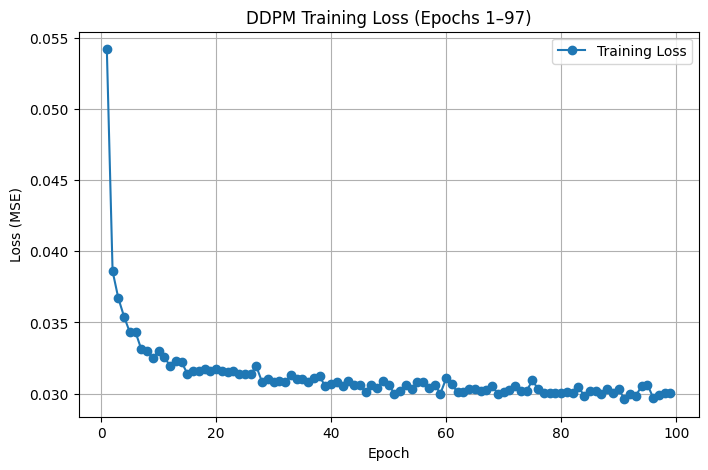

In [ ]:
import re
import matplotlib.pyplot as plt

# Path to your merged log file
log_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/epoch loss.txt"

# Read all text
with open(log_path, "r") as f:
    text = f.read()

# Extract all loss values from lines like "Loss: 0.0343"
losses = [float(x) for x in re.findall(r"Loss:\s*([0-9.]+)", text)]

print(f"✅ Extracted {len(losses)} losses:", losses[:10], "...")

# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(range(1, len(losses)+1), losses, marker='o', label="Training Loss")
plt.title("DDPM Training Loss (Epochs 1–100)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm_conditional.py
# ============================================================
# DDPM Conditional Training Script (with Auto Resume)
# ============================================================
import argparse, logging, copy, os, glob
from types import SimpleNamespace
import torch
from torch import optim
import torch.nn as nn
import numpy as np
import fastprogress
from fastprogress import progress_bar
from matplotlib import pyplot as plt
import wandb

# Disable progress bars globally
fastprogress.fastprogress.NO_BAR = True
fastprogress.fastprogress.WRITER_FN = False

from utils import *
from modules.modules import UNet_conditional, EMA

torch.cuda.empty_cache()

# ============================================================
# Configuration
# ============================================================
config = SimpleNamespace(
    run_name="DDPM_conditional",
    epochs=100,
    noise_steps=1000,
    seed=42,
    batch_size=10,
    img_size=32,
    num_classes=10,
    dataset_path=get_cifar(img_size=32),
    train_folder="train",
    val_folder="test",
    device="cuda:0",
    slice_size=1,
    do_validation=True,
    fp16=True,
    log_every_epoch=10,
    num_workers=10,
    lr=5e-3
)

# ============================================================
# Logging
# ============================================================
logging.basicConfig(format="%(asctime)s - %(levelname)s: %(message)s",
                    level=logging.INFO, datefmt="%I:%M:%S")

# ============================================================
# Diffusion Class
# ============================================================
class Diffusion:
    def __init__(self, noise_steps=1000, beta_start=1e-4, beta_end=0.02,
                 img_size=32, num_classes=10, c_in=3, c_out=3, device="cuda:0", **kwargs):
        self.noise_steps = noise_steps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.beta = self.prepare_noise_schedule().to(device)
        self.alpha = 1. - self.beta
        self.alpha_hat = torch.cumprod(self.alpha, dim=0)

        self.img_size = img_size
        self.model = UNet_conditional(c_in, c_out, num_classes=num_classes, **kwargs).to(device)
        self.ema_model = copy.deepcopy(self.model).eval().requires_grad_(False)
        self.device = device
        self.c_in = c_in
        self.num_classes = num_classes

    def prepare_noise_schedule(self):
        return torch.linspace(self.beta_start, self.beta_end, self.noise_steps)

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.noise_steps, size=(n,))

    def noise_images(self, x, t):
        sqrt_alpha_hat = torch.sqrt(self.alpha_hat[t])[:, None, None, None]
        sqrt_one_minus_alpha_hat = torch.sqrt(1 - self.alpha_hat[t])[:, None, None, None]
        Ɛ = torch.randn_like(x)
        return sqrt_alpha_hat * x + sqrt_one_minus_alpha_hat * Ɛ, Ɛ

    def train_step(self, loss):
        self.optimizer.zero_grad()
        self.scaler.scale(loss).backward()
        self.scaler.step(self.optimizer)
        self.scaler.update()
        self.ema.step_ema(self.ema_model, self.model)
        self.scheduler.step()

    def one_epoch(self, train=True):
        avg_loss = 0.
        data_loader = self.train_dataloader if train else self.val_dataloader
        self.model.train() if train else self.model.eval()

        for i, (images, labels) in enumerate(data_loader):
            with torch.autocast("cuda"):
                images = images.to(self.device)
                labels = labels.to(self.device)
                t = self.sample_timesteps(images.shape[0]).to(self.device)
                x_t, noise = self.noise_images(images, t)
                if np.random.random() < 0.1:
                    labels = None
                predicted_noise = self.model(x_t, t, labels)
                loss = self.mse(noise, predicted_noise)
                avg_loss += loss.item()

            if train:
                self.train_step(loss)
                wandb.log({
                    "train_mse_step": loss.item(),
                    "learning_rate": self.scheduler.get_last_lr()[0]
                })
        return avg_loss / len(data_loader)

    def prepare(self, args):
        mk_folders(args.run_name)
        self.train_dataloader, self.val_dataloader = get_data(args)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=args.lr, eps=1e-5)
        self.scheduler = optim.lr_scheduler.OneCycleLR(self.optimizer, max_lr=args.lr,
                                                       steps_per_epoch=len(self.train_dataloader), epochs=args.epochs)
        self.mse = nn.MSELoss()
        self.ema = EMA(0.995)
        self.scaler = torch.cuda.amp.GradScaler()

    def save_checkpoint(self, epoch, losses):
        """Save model and loss in 'checkpoints_conditional' after each epoch"""
        os.makedirs("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional", exist_ok=True)
        checkpoint_path = f"/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional/epoch_{epoch+1}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'losses': losses
        }, checkpoint_path)
        logging.info(f"💾 Saved checkpoint: {checkpoint_path}")

    def load_latest_checkpoint(self):
        ckpt_dir = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional"
        if not os.path.exists(ckpt_dir):
            return 0, []
        ckpts = sorted(glob.glob(os.path.join(ckpt_dir, "epoch_*.pt")), key=os.path.getmtime)
        if len(ckpts) == 0:
            return 0, []
        latest_ckpt = ckpts[-1]
        checkpoint = torch.load(latest_ckpt, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        last_epoch = checkpoint['epoch'] + 1
        train_losses = checkpoint['losses']
        logging.info(f"🔄 Resumed from checkpoint: {latest_ckpt} (Epoch {last_epoch})")
        wandb.log({"resumed_epoch": last_epoch})
        return last_epoch, train_losses

    def fit(self, args):
        start_epoch, train_losses = self.load_latest_checkpoint()
        total_epochs = args.epochs

        for epoch in range(start_epoch, total_epochs):
            logging.info(f"🚀 Starting epoch {epoch + 1}/{total_epochs} ...")
            avg_loss = self.one_epoch(train=True)
            train_losses.append(avg_loss)
            wandb.log({"train_mse_epoch": avg_loss})

            # Log training loss to console
            logging.info(f"📉 Epoch {epoch+1} | Train Loss: {avg_loss:.6f}")

            if args.do_validation:
                val_loss = self.one_epoch(train=False)
                wandb.log({"val_mse_epoch": val_loss})
                logging.info(f"✅ Epoch {epoch+1} | Validation Loss: {val_loss:.6f}")

            # Save checkpoint **after every epoch**
            self.save_checkpoint(epoch, train_losses)

        # ===============================
        # Plot and Save Loss Curve
        # ===============================
        os.makedirs("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/loss_curve", exist_ok=True)
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label="Training Loss")
        plt.title(f"DDPM Conditional Training Loss (Epochs 1–{args.epochs})")
        plt.xlabel("Epoch")
        plt.ylabel("Loss (MSE)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        loss_curve_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/loss_curve/loss_curve_conditional.png"
        plt.savefig(loss_curve_path)
        plt.close()
        logging.info(f"📊 Saved final loss curve: {loss_curve_path}")

# ============================================================
# Parse Arguments
# ============================================================
def parse_args(config):
    parser = argparse.ArgumentParser(description='Process hyper-parameters')
    parser.add_argument('--run_name', type=str, default=config.run_name)
    parser.add_argument('--epochs', type=int, default=config.epochs)
    parser.add_argument('--seed', type=int, default=config.seed)
    parser.add_argument('--batch_size', type=int, default=config.batch_size)
    parser.add_argument('--img_size', type=int, default=config.img_size)
    parser.add_argument('--num_classes', type=int, default=config.num_classes)
    parser.add_argument('--dataset_path', type=str, default=config.dataset_path)
    parser.add_argument('--device', type=str, default=config.device)
    parser.add_argument('--lr', type=float, default=config.lr)
    parser.add_argument('--slice_size', type=int, default=config.slice_size)
    parser.add_argument('--noise_steps', type=int, default=config.noise_steps)
    args = vars(parser.parse_args())
    for k, v in args.items():
        setattr(config, k, v)

# ============================================================
# Main
# ============================================================
if __name__ == '__main__':
    parse_args(config)
    set_seed(config.seed)
    diffuser = Diffusion(config.noise_steps, img_size=config.img_size, num_classes=config.num_classes)
    with wandb.init(project="train_sd", group="train", config=config):
        diffuser.prepare(config)
        diffuser.fit(config)


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm_conditional.py


In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm_conditional.py

Traceback (most recent call last):
  File "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm_conditional.py", line 19, in <module>
    from utils import *
  File "/content/drive/.shortcut-targets-by-id/1u6aArvTMPuwQhmL0dFEB_C0Cf_lO_JVi/NN_RESEARCH/biodiffusion/src/utils.py", line 4, in <module>
    from kaggle import api
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm_conditional.py

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit: 
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: deepalitalreja02 (deepalitalreja02-faculty-of-technology-university-of-delhi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wand

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ddpm_conditional.py

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: 2
wandb: You chose 'Use an existing W&B account'
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit: 
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: deepalitalreja02 (deepalitalreja02-faculty-of-technology-university-of-delhi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run o

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/load_dataset.py

Dataset URL: https://www.kaggle.com/datasets/shayanfazeli/heartbeat


In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py
import os
import copy
import sys
sys.path.insert(0, './modules/')
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from torch import optim
from utils import *
from modules.modules1D_cls_free import Unet1D_cls_free, GaussianDiffusion1D_cls_free
import logging
from torch.utils.tensorboard import SummaryWriter
from MITBIH import *
from torch.utils import data

logging.basicConfig(format="%(asctime)s - %(levelname)s: %(message)s", level=logging.INFO, datefmt="%I:%M:%S")
data_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/datasets/heartbeat/mitbih_train.csv"

class TrainingDataset(data.Dataset):
    """
    Custom PyTorch Dataset for training.
    """
    def __init__(self, filename):
        self.fiveClassECG = mitbih_allClass(filename=filename)

    def __len__(self):
        return len(self.fiveClassECG)

    def __getitem__(self, idx):
        signals, labels = self.fiveClassECG[idx]
        return signals, labels



def train(args):
    """
    Training function for the Deep Diffusion Probabilistic Model (DDPM) on 1D signals with classification.

    Parameters:
        - args (argparse.Namespace): Command-line arguments.
    """
    setup_logging(args.run_name)
    device = args.device
    dataset = TrainingDataset(filename=data_path)
    dataloader = data.DataLoader(dataset, batch_size=args.batch_size, num_workers=4, shuffle=True)
    classes = 5

    # Define the UNet model
    model = Unet1D_cls_free(
        dim=64,
        dim_mults=(1, 2, 4, 8),
        num_classes=args.num_classes,
        cond_drop_prob=0.5,
        channels=1
    ).to(device)

    # Define the Gaussian Diffusion model
    diffusion = GaussianDiffusion1D_cls_free(
        model,
        seq_length=128,
        timesteps=1000
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=args.lr)
    logger = SummaryWriter(os.path.join("runs", args.run_name))
    l = len(dataloader)

    #directory for checkpoints
    loss_curve_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/loss_cuve"
    os.makedirs(loss_curve_path, exist_ok=True)
    os.makedirs(args.checkpoint_dir, exist_ok=True)
    epoch_losses = []
    for epoch in range(args.epochs):
        logging.info(f"Starting epoch {epoch}:")
        pbar = tqdm(dataloader)
        total_loss = 0.0
        for i, (signals, labels) in enumerate(pbar):
            signals = signals.to(device).to(torch.float)
            labels = labels.to(device).to(torch.long)

            # Calculate loss using the diffusion model
            loss = diffusion(signals, classes=labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            logger.add_scalar("loss", loss.item(), global_step=epoch * l + i)
        avg_epoch_loss = total_loss / l
        epoch_losses.append(avg_epoch_loss)
        logging.info(f"Epoch [{epoch}] Average Loss: {avg_epoch_loss:.6f}")

        # Generate and save sampled signals
        labels = torch.randint(0, args.num_classes, (10,)).to(device)
        sampled_signals = diffusion.sample(
            classes=labels,
            cond_scale=3.
        )

        # Save the generated signals as images
        save_signals_cls_free(sampled_signals, labels, os.path.join("results", args.run_name, f"{epoch}.jpg"))

        # Save model checkpoint
        checkpoint_path = os.path.join(args.checkpoint_dir, f"{args.run_name}_epoch{epoch+1}.pt")
        torch.save({
            'epoch': epoch + 1,
            'model': model,
            'model_state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch_loss': avg_epoch_loss,
        },checkpoint_path)

        logging.info(f"Checkpoint saved at: {checkpoint_path}")



        plt.figure()
        plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
        plt.xlabel("Epoch")
        plt.ylabel("Average Loss")
        plt.title(f"Training Loss Curve - {args.run_name}")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(loss_curve_path, "loss_curve_ddpm_1d_cls_free.png"))
        plt.close()

def launch():
    """
    Launch the training process with predefined parameters.
    """
    import argparse
    parser = argparse.ArgumentParser()
    args = parser.parse_args()
    args.run_name = "DDPM1D_cls_free_MITBIH"
    args.epochs = 300
    args.batch_size = 64
    args.seq_length = 128
    args.num_classes = 5
    args.device = "cuda:0"
    args.lr = 3e-4

    args.checkpoint_dir = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_1D_cls_MITBIH"
    train(args)



if __name__ == '__main__':
    launch()

Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py


In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py

2025-11-13 15:57:09.695832: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763049429.727864    7213 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763049429.737945    7213 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763049429.763473    7213 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763049429.763507    7213 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763049429.763514    7213 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py

2025-11-14 02:10:24.852151: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763086224.873182    1456 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763086224.879426    1456 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763086224.895093    1456 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763086224.895119    1456 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763086224.895124    1456 computation_placer.cc:177] computation placer alr

In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py
import os
import sys
sys.path.insert(0, './modules/')
import glob
import logging
import numpy as np
import torch
import torch.nn as nn
from torch.nn.modules.container import ModuleList
from torch import optim
from torch.utils import data
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import matplotlib.pyplot as plt

from utils import *
from modules.modules1D_cls_free import (
    Unet1D_cls_free,
    GaussianDiffusion1D_cls_free,
    SinusoidalPosEmb,
    RandomOrLearnedSinusoidalPosEmb,
    ResnetBlock,
    Block,
    WeightStandardizedConv2d,
    Residual,
    PreNorm,
    LinearAttention,
    Attention,
    LayerNorm,
    Upsample,
    Downsample,
    EMA,
    ModelPrediction
)
from MITBIH import *

# -----------------------------
# Safe Globals for PyTorch 2.6+ Checkpoint Loading
# -----------------------------
torch.serialization.add_safe_globals([
    ModuleList,
    nn.Conv1d,
    nn.Conv2d,
    nn.Linear,
    nn.BatchNorm1d,
    nn.BatchNorm2d,
    nn.LayerNorm,
    nn.GroupNorm,
    nn.Embedding,
    nn.ReLU,
    nn.SiLU,
    nn.GELU,
    nn.Identity,
    nn.Sequential,
    # Custom modules
    Unet1D_cls_free,
    GaussianDiffusion1D_cls_free,
    SinusoidalPosEmb,
    RandomOrLearnedSinusoidalPosEmb,
    ResnetBlock,
    Block,
    WeightStandardizedConv2d,
    Residual,
    PreNorm,
    LinearAttention,
    Attention,
    LayerNorm,
    Upsample,
    Downsample,
    EMA,
    ModelPrediction
])

logging.basicConfig(
    format="%(asctime)s - %(levelname)s: %(message)s",
    level=logging.INFO,
    datefmt="%I:%M:%S"
)

data_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/datasets/heartbeat/mitbih_train.csv"

# -----------------------------
# Custom Dataset
# -----------------------------
class TrainingDataset(data.Dataset):
    def __init__(self, filename):
        self.fiveClassECG = mitbih_allClass(filename=filename)

    def __len__(self):
        return len(self.fiveClassECG)

    def __getitem__(self, idx):
        signals, labels = self.fiveClassECG[idx]
        return signals, labels

# -----------------------------
# Checkpoint Loader
# -----------------------------
def load_latest_checkpoint(model, optimizer, device, ckpt_dir, run_name):
    """
    Loads the latest checkpoint matching <run_name>_epoch*.pt
    Returns: last_epoch, last_epoch_loss
    """
    if not os.path.exists(ckpt_dir):
        return 0, None

    pattern = f"{run_name}_epoch*.pt"
    ckpts = sorted(glob.glob(os.path.join(ckpt_dir, pattern)), key=os.path.getmtime)
    if len(ckpts) == 0:
        return 0, None

    latest_ckpt = ckpts[-1]

    # Use weights_only=False for full state loading
    checkpoint = torch.load(latest_ckpt, map_location=device, weights_only=False)

    # Load model state_dict
    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        logging.warning(f"Checkpoint {latest_ckpt} does not contain 'model_state_dict'.")

    # Load optimizer state_dict if it exists
    if "optimizer_state_dict" in checkpoint and optimizer is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    else:
        logging.warning(f"Checkpoint {latest_ckpt} does not contain 'optimizer_state_dict' or optimizer is None.")

    # Epoch info
    last_epoch = checkpoint.get("epoch", 0)
    last_epoch_loss = checkpoint.get("epoch_loss", None)

    logging.info(f"Loaded checkpoint: {latest_ckpt} (Epoch {last_epoch})")
    return last_epoch, last_epoch_loss


# -----------------------------
# Training Function
# -----------------------------
def train(args):
    setup_logging(args.run_name)
    device = args.device
    dataset = TrainingDataset(filename=data_path)
    dataloader = data.DataLoader(dataset, batch_size=args.batch_size, num_workers=4, shuffle=True)
    classes = args.num_classes

    # UNet model
    model = Unet1D_cls_free(
        dim=64,
        dim_mults=(1, 2, 4, 8),
        num_classes=classes,
        cond_drop_prob=0.5,
        channels=1
    ).to(device)

    # Diffusion model
    diffusion = GaussianDiffusion1D_cls_free(
        model,
        seq_length=args.seq_length,
        timesteps=1000
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=args.lr)
    logger = SummaryWriter(os.path.join("runs", args.run_name))
    l = len(dataloader)

    # Directories
    loss_curve_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/loss_curve"
    os.makedirs(loss_curve_path, exist_ok=True)
    os.makedirs(args.checkpoint_dir, exist_ok=True)

    epoch_losses = []

    # Resume from checkpoint
    start_epoch, last_loss = load_latest_checkpoint(model, optimizer, device, args.checkpoint_dir, args.run_name)
    if last_loss is not None:
        epoch_losses.append(last_loss)

    # -----------------------------
    # Training Loop
    # -----------------------------
    for epoch in range(start_epoch, args.epochs):
        logging.info(f"Starting epoch {epoch}:")
        pbar = tqdm(dataloader)
        total_loss = 0.0

        for i, (signals, labels) in enumerate(pbar):
            signals = signals.to(device).to(torch.float)
            labels = labels.to(device).to(torch.long)

            loss = diffusion(signals, classes=labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            logger.add_scalar("loss", loss.item(), global_step=epoch * l + i)

        avg_epoch_loss = total_loss / l
        epoch_losses.append(avg_epoch_loss)
        logging.info(f"Epoch [{epoch}] Average Loss: {avg_epoch_loss:.6f}")

        # Generate sample signals
        labels = torch.randint(0, classes, (10,)).to(device)
        sampled_signals = diffusion.sample(classes=labels, cond_scale=3.0)

        save_signals_cls_free(
            sampled_signals,
            labels,
            os.path.join("results", args.run_name, f"{epoch}.jpg")
        )

        # Save checkpoint
        checkpoint_path = os.path.join(args.checkpoint_dir, f"{args.run_name}_epoch{epoch+1}.pt")
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch_loss': avg_epoch_loss,
        }, checkpoint_path)
        logging.info(f"Checkpoint saved at: {checkpoint_path}")

        # Plot loss curve
        plt.figure()
        plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
        plt.xlabel("Epoch")
        plt.ylabel("Average Loss")
        plt.title(f"Training Loss Curve - {args.run_name}")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(loss_curve_path, "loss_curve_ddpm_1d_cls_free.png"))
        plt.close()

# -----------------------------
# Launch Function
# -----------------------------
def launch():
    import argparse
    parser = argparse.ArgumentParser()
    args = parser.parse_args()
    args.run_name = "DDPM1D_cls_free_MITBIH"
    args.epochs = 300
    args.batch_size = 64
    args.seq_length = 128
    args.num_classes = 5
    args.device = "cuda:0"
    args.lr = 3e-4
    args.checkpoint_dir = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_1D_cls_MITBIH"

    train(args)

if __name__ == '__main__':
    launch()


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py


In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py

2025-11-14 04:26:06.981784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763094367.001945   22358 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763094367.008066   22358 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763094367.023391   22358 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763094367.023424   22358 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763094367.023428   22358 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py

2025-11-14 05:04:22.808447: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763096662.827815    1426 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763096662.833690    1426 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763096662.848417    1426 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763096662.848440    1426 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763096662.848446    1426 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py

2025-11-14 07:56:08.684505: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763106968.715894    3232 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763106968.725235    3232 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763106968.748091    3232 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763106968.748131    3232 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763106968.748140    3232 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py

2025-11-14 14:09:54.277915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763129394.297219    3133 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763129394.303690    3133 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763129394.320610    3133 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763129394.320632    3133 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763129394.320638    3133 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py

2025-11-14 19:18:19.308963: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763147899.328236    3596 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763147899.334347    3596 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763147899.349258    3596 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763147899.349285    3596 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763147899.349289    3596 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_cls_free.py

2025-11-15 01:35:58.687544: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763170558.707755    1494 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763170558.713696    1494 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763170558.729285    1494 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763170558.729318    1494 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763170558.729322    1494 computation_placer.cc:177] computation placer alr

✅ Extracted 298 losses: [0.163569, 0.138482, 0.132606, 0.129317, 0.128067, 0.126441, 0.125295, 0.124398, 0.12348, 0.122989] ...


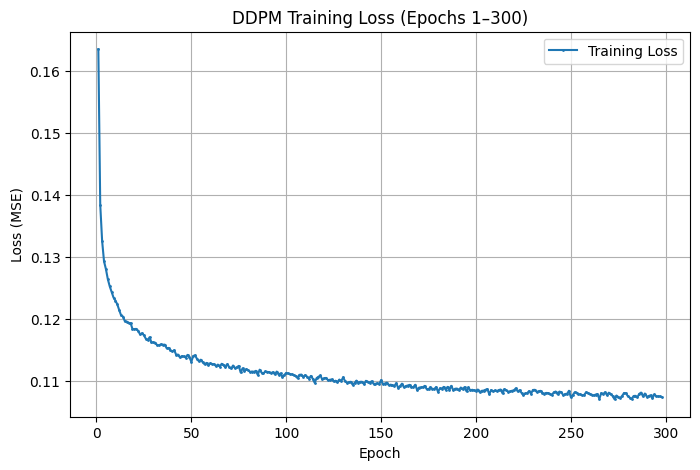

In [ ]:
import re
import matplotlib.pyplot as plt

# Path to your merged log file
log_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/ddpm_1d_cls_loss.txt"

# Read all text
with open(log_path, "r") as f:
    text = f.read()

# Extract values after "Average Loss:"
losses = [float(x) for x in re.findall(r"Average Loss:\s*([0-9.]+)", text)]

print(f"✅ Extracted {len(losses)} losses:", losses[:10], "...")

# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(range(1, len(losses)+1), losses, marker='o', markersize = 1 , label="Training Loss")
plt.title("DDPM Training Loss (Epochs 1–300)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_sign_cond.py
import os
import sys
sys.path.insert(0, './modules/')

import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from tqdm import tqdm
from torch import optim
from utils_cond import *
from modules.modules1D_cond import Unet1D, GaussianDiffusion1D
import logging
from torch.utils.tensorboard import SummaryWriter
from MITBIH import *
from torch.utils import data
import random

logging.basicConfig(format="%(asctime)s - %(levelname)s: %(message)s",
                    level=logging.INFO, datefmt="%I:%M:%S")

data_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/datasets/heartbeat/mitbih_train.csv"


# --------------------------------------------------------------------------------
# Dataset
# --------------------------------------------------------------------------------
class TrainingDataset(data.Dataset):
    def __init__(self, filename, class_id):
        self.cond_ECG = mitbih_masked(filename=filename, class_id=class_id)

    def __len__(self):
        return len(self.cond_ECG)

    def __getitem__(self, idx):
        return {
            'org_data': self.cond_ECG[idx]['org_data'],
            'cond_data': self.cond_ECG[idx]['cond_data']
        }


# --------------------------------------------------------------------------------
# Checkpoint utilities
# --------------------------------------------------------------------------------
def save_checkpoint(epoch, model, optimizer, loss, path):
    os.makedirs(path, exist_ok=True)
    ckpt_path = os.path.join(path, f"epoch_{epoch}.pt")

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }, ckpt_path)

    logging.info(f"Checkpoint saved: {ckpt_path}")


def load_checkpoint(model, optimizer, path):
    if not os.path.exists(path):
        logging.info("No checkpoint found. Starting fresh training...")
        return 0  # Start at epoch 0

    ckpt = torch.load(path, map_location="cpu")
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch = ckpt['epoch'] + 1

    logging.info(f"Resuming training from epoch {start_epoch}")
    return start_epoch


# --------------------------------------------------------------------------------
# Training
# --------------------------------------------------------------------------------
def train(args):
    setup_logging(args.run_name)
    device = args.device

    # Create folders
    checkpoint_dir = f"/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_1d_signal_conditional/{args.run_name}"
    result_dir = f"/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/{args.run_name}"
    loss_curve_dir = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/loss_curve"

    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(result_dir, exist_ok=True)
    os.makedirs(loss_curve_dir, exist_ok=True)

    # Dataset
    dataset = TrainingDataset(filename=data_path, class_id=0)
    dataloader = data.DataLoader(dataset, batch_size=args.batch_size, num_workers=4, shuffle=True)

    # Model
    model = Unet1D(
        dim=64,
        self_condition=True,
        dim_mults=(1, 2, 4, 8),
        channels=1
    ).to(device)

    diffusion = GaussianDiffusion1D(
        model,
        seq_length=128,
        timesteps=1000,
        objective='pred_v'
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=args.lr)
    logger = SummaryWriter(os.path.join("runs", args.run_name))

    # Resume training if checkpoint exists
    last_ckpt_path = os.path.join(checkpoint_dir, "latest.pt")
    start_epoch = load_checkpoint(model, optimizer, last_ckpt_path)

    # Track loss
    epoch_losses = []

    l = len(dataloader)

    for epoch in range(start_epoch, args.epochs):
        logging.info(f"Starting epoch {epoch}")
        pbar = tqdm(dataloader)
        running_loss = 0

        for i, data_dict in enumerate(pbar):
            sig1 = data_dict['org_data'].to(device).to(torch.float)
            sig2 = data_dict['cond_data'].to(device).to(torch.float)

            loss = diffusion(sig1, sig2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            logger.add_scalar("loss", loss.item(), global_step=epoch * l + i)

        avg_loss = running_loss / l
        epoch_losses.append(avg_loss)

        # Generate samples
        index_list = list(range(len(dataset)))
        random.shuffle(index_list)
        cond_data = torch.from_numpy(dataset.cond_ECG.cond_data[index_list][:args.sample_size])
        cond_data = cond_data.to(device).float()

        sampled_signals = diffusion.sample(batch_size=args.sample_size, input_cond=cond_data)

        # Save image
        save_path = os.path.join(result_dir, f"epoch_{epoch}.jpg")
        save_signals(sampled_signals, save_path)

        # Save checkpoint for this epoch
        save_checkpoint(epoch, model, optimizer, avg_loss, checkpoint_dir)

        # Save "latest.pt" for resume
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss
        }, last_ckpt_path)

    # ------------------------------------------
    # Save Loss Curve
    # ------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(epoch_losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("DDPM 1D Signal Loss Curve")
    loss_curve_path = f"{loss_curve_dir}/loss_ddpm_1d_signal.png"
    plt.savefig(loss_curve_path)
    plt.close()

    logging.info(f"Loss curve saved to: {loss_curve_path}")


# --------------------------------------------------------------------------------
# Launcher
# --------------------------------------------------------------------------------
def launch():
    import argparse
    parser = argparse.ArgumentParser()
    args = parser.parse_args()

    args.run_name = "DDPM1D_Selfcond_maskedCond"
    args.epochs = 100
    args.batch_size = 32
    args.device = "cuda:0"
    args.lr = 3e-4
    args.sample_size = 10

    train(args)


if __name__ == '__main__':
    launch()


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_sign_cond.py


In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_sign_cond.py

2025-11-15 06:59:06.774712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763189946.806825    2569 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763189946.816605    2569 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763189946.839375    2569 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763189946.839407    2569 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763189946.839416    2569 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_sign_cond.py

2025-11-15 10:40:12.876840: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763203212.912502    1471 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763203212.923571    1471 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763203212.947931    1471 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763203212.947960    1471 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763203212.947965    1471 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_sign_cond.py

2025-11-15 19:09:39.864303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763233779.895896    2073 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763233779.905951    2073 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763233779.935872    2073 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763233779.935900    2073 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763233779.935904    2073 computation_placer.cc:177] computation placer alr

In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/ddpm1d_sign_cond.py

2025-11-16 02:35:52.384468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763260552.406738    1754 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763260552.413270    1754 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763260552.428447    1754 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763260552.428472    1754 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763260552.428476    1754 computation_placer.cc:177] computation placer alr

In [ ]:
!ls /content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_1d_signal_conditional/DDPM1D_Selfcond_maskedCond

epoch_0.pt   epoch_25.pt  epoch_40.pt  epoch_56.pt  epoch_71.pt  epoch_87.pt
epoch_10.pt  epoch_26.pt  epoch_41.pt  epoch_57.pt  epoch_72.pt  epoch_88.pt
epoch_11.pt  epoch_27.pt  epoch_42.pt  epoch_58.pt  epoch_73.pt  epoch_89.pt
epoch_12.pt  epoch_28.pt  epoch_43.pt  epoch_59.pt  epoch_74.pt  epoch_8.pt
epoch_13.pt  epoch_29.pt  epoch_44.pt  epoch_5.pt   epoch_75.pt  epoch_90.pt
epoch_14.pt  epoch_2.pt   epoch_45.pt  epoch_60.pt  epoch_76.pt  epoch_91.pt
epoch_15.pt  epoch_30.pt  epoch_46.pt  epoch_61.pt  epoch_77.pt  epoch_92.pt
epoch_16.pt  epoch_31.pt  epoch_47.pt  epoch_62.pt  epoch_78.pt  epoch_93.pt
epoch_17.pt  epoch_32.pt  epoch_48.pt  epoch_63.pt  epoch_79.pt  epoch_94.pt
epoch_18.pt  epoch_33.pt  epoch_49.pt  epoch_64.pt  epoch_7.pt	 epoch_95.pt
epoch_19.pt  epoch_34.pt  epoch_4.pt   epoch_65.pt  epoch_80.pt  epoch_96.pt
epoch_1.pt   epoch_35.pt  epoch_50.pt  epoch_66.pt  epoch_81.pt  epoch_97.pt
epoch_20.pt  epoch_36.pt  epoch_51.pt  epoch_67.pt  epoch_82.pt  epoch_98.pt
e

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint_path = f"/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_1d_signal_conditional/DDPM1D_Selfcond_maskedCond/epoch_14.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)
print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'])


🔍 Trying to load epoch_0.pt
✅ Loaded epoch 0
🔍 Trying to load epoch_1.pt
✅ Loaded epoch 1
🔍 Trying to load epoch_2.pt
✅ Loaded epoch 2
🔍 Trying to load epoch_3.pt
✅ Loaded epoch 3
🔍 Trying to load epoch_4.pt
✅ Loaded epoch 4
🔍 Trying to load epoch_5.pt
✅ Loaded epoch 5
🔍 Trying to load epoch_6.pt
✅ Loaded epoch 6
🔍 Trying to load epoch_7.pt
✅ Loaded epoch 7
🔍 Trying to load epoch_8.pt
✅ Loaded epoch 8
🔍 Trying to load epoch_9.pt
✅ Loaded epoch 9
🔍 Trying to load epoch_10.pt
✅ Loaded epoch 10
🔍 Trying to load epoch_11.pt
✅ Loaded epoch 11
🔍 Trying to load epoch_12.pt
✅ Loaded epoch 12
🔍 Trying to load epoch_13.pt
✅ Loaded epoch 13
🔍 Trying to load epoch_14.pt
✅ Loaded epoch 14
🔍 Trying to load epoch_15.pt
✅ Loaded epoch 15
🔍 Trying to load epoch_16.pt
✅ Loaded epoch 16
🔍 Trying to load epoch_17.pt
✅ Loaded epoch 17
🔍 Trying to load epoch_18.pt
✅ Loaded epoch 18
🔍 Trying to load epoch_19.pt
✅ Loaded epoch 19
🔍 Trying to load epoch_20.pt
✅ Loaded epoch 20
🔍 Trying to load epoch_21.pt
✅ Lo

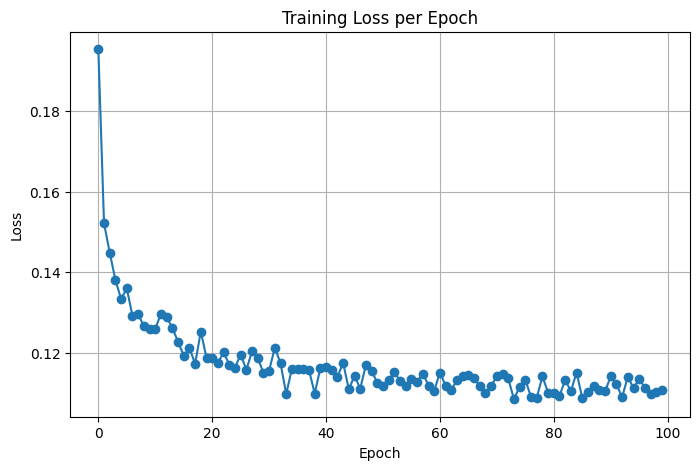

In [ ]:
import torch
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

losses = []
epochs = []

for x in range(0, 100):

    print(f"🔍 Trying to load epoch_{x}.pt")   # <-- DEBUG PRINT

    checkpoint_path = f"/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_1d_signal_conditional/DDPM1D_Selfcond_maskedCond/epoch_{x}.pt"

    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        print(f"Loaded epoch {x}")

        if 'loss' in checkpoint:
            losses.append(checkpoint['loss'])
            epochs.append(x)

    except FileNotFoundError:
        print(f"Not found: epoch_{x}.pt")
        continue

# Plot
if losses:
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, losses, marker='o')
    plt.title("Training Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()


In [ ]:
!ls /content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional

epoch_100.pt  epoch_25.pt  epoch_40.pt	epoch_56.pt  epoch_71.pt  epoch_87.pt
epoch_10.pt   epoch_26.pt  epoch_41.pt	epoch_57.pt  epoch_72.pt  epoch_88.pt
epoch_11.pt   epoch_27.pt  epoch_42.pt	epoch_58.pt  epoch_73.pt  epoch_89.pt
epoch_12.pt   epoch_28.pt  epoch_43.pt	epoch_59.pt  epoch_74.pt  epoch_8.pt
epoch_13.pt   epoch_29.pt  epoch_44.pt	epoch_5.pt   epoch_75.pt  epoch_90.pt
epoch_14.pt   epoch_2.pt   epoch_45.pt	epoch_60.pt  epoch_76.pt  epoch_91.pt
epoch_15.pt   epoch_30.pt  epoch_46.pt	epoch_61.pt  epoch_77.pt  epoch_92.pt
epoch_16.pt   epoch_31.pt  epoch_47.pt	epoch_62.pt  epoch_78.pt  epoch_93.pt
epoch_17.pt   epoch_32.pt  epoch_48.pt	epoch_63.pt  epoch_79.pt  epoch_94.pt
epoch_18.pt   epoch_33.pt  epoch_49.pt	epoch_64.pt  epoch_7.pt   epoch_95.pt
epoch_19.pt   epoch_34.pt  epoch_4.pt	epoch_65.pt  epoch_80.pt  epoch_96.pt
epoch_1.pt    epoch_35.pt  epoch_50.pt	epoch_66.pt  epoch_81.pt  epoch_97.pt
epoch_20.pt   epoch_36.pt  epoch_51.pt	epoch_67.pt  epoch_82.pt  epoch_98.pt
e

In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

checkpoint_path = f"/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional/epoch_99.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)
print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'losses'])


🔍 Trying to load epoch_1.pt
Loaded epoch 1
🔍 Trying to load epoch_2.pt
Loaded epoch 2
🔍 Trying to load epoch_3.pt
Loaded epoch 3
🔍 Trying to load epoch_4.pt
Loaded epoch 4
🔍 Trying to load epoch_5.pt
Loaded epoch 5
🔍 Trying to load epoch_6.pt
Loaded epoch 6
🔍 Trying to load epoch_7.pt
Loaded epoch 7
🔍 Trying to load epoch_8.pt
Loaded epoch 8
🔍 Trying to load epoch_9.pt
Loaded epoch 9
🔍 Trying to load epoch_10.pt
Loaded epoch 10
🔍 Trying to load epoch_11.pt
Loaded epoch 11
🔍 Trying to load epoch_12.pt
Loaded epoch 12
🔍 Trying to load epoch_13.pt
Loaded epoch 13
🔍 Trying to load epoch_14.pt
Loaded epoch 14
🔍 Trying to load epoch_15.pt
Loaded epoch 15
🔍 Trying to load epoch_16.pt
Loaded epoch 16
🔍 Trying to load epoch_17.pt
Loaded epoch 17
🔍 Trying to load epoch_18.pt
Loaded epoch 18
🔍 Trying to load epoch_19.pt
Loaded epoch 19
🔍 Trying to load epoch_20.pt
Loaded epoch 20
🔍 Trying to load epoch_21.pt
Loaded epoch 21
🔍 Trying to load epoch_22.pt
Loaded epoch 22
🔍 Trying to load epoch_23.pt

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (100,) + inhomogeneous part.

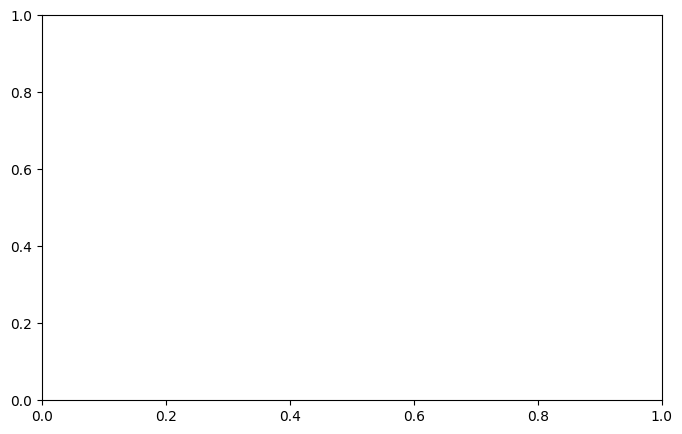

In [ ]:
import torch
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

losses = []
epochs = []

for x in range(1, 101):

    print(f"🔍 Trying to load epoch_{x}.pt")   # <-- DEBUG PRINT

    checkpoint_path = f"/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional/epoch_{x}.pt"

    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        print(f"Loaded epoch {x}")

        if 'losses' in checkpoint:
            losses.append(checkpoint['losses'])
            epochs.append(x)

    except FileNotFoundError:
        print(f"Not found: epoch_{x}.pt")
        continue

# Plot
if losses:
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, losses, marker='o')
    plt.title("Training Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()


Extracted Train Losses: [0.061149, 0.039335, 0.037354, 0.035909, 0.034441, 0.034285, 0.03348, 0.034092, 0.033691, 0.033834]
Total epochs found: 84


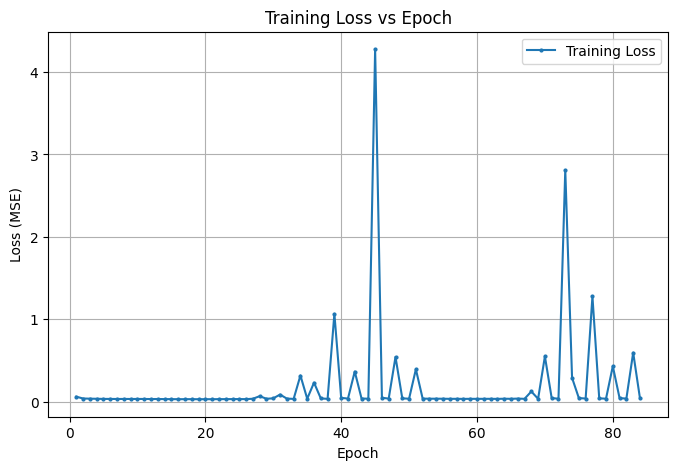

In [ ]:
import re
import matplotlib.pyplot as plt

# Path to your merged log file
log_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/ddpm_1d_conditional.txt"

# Read full log file
with open(log_path, "r") as f:
    text = f.read()

# Extract ONLY "Train Loss: <float>"
train_losses = [float(x) for x in re.findall(r"Train Loss:\s*([0-9]*\.[0-9]+)", text)]

print("Extracted Train Losses:", train_losses[:10])
print("Total epochs found:", len(train_losses))

# Plot the training loss vs epochs
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', markersize=2, label="Training Loss")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
%%writefile /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/generate_signal_code.py
import os
import torch
import numpy as np
import random
import sys
sys.path.insert(0, "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/src")

from ecg_signal.modules.modules1D_cond import Unet1D, GaussianDiffusion1D
from ecg_signal.MITBIH import mitbih_masked

device = "cuda"

# ----------------------------------------------
# PATHS
# ----------------------------------------------
checkpoint_dir = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_1d_signal_conditional/DDPM1D_Selfcond_maskedCond"
save_dir = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/DDPM1D_Selfcond_maskedCond/random_epoch_samples"
os.makedirs(save_dir, exist_ok=True)

# ----------------------------------------------
# Select 10 random epoch checkpoints
# ----------------------------------------------
all_epochs = []

for f in os.listdir(checkpoint_dir):
    if f.startswith("epoch_") and f.endswith(".pt"):
        num = int(f.replace("epoch_", "").replace(".pt", ""))
        all_epochs.append(num)

all_epochs = sorted(all_epochs)

random_epochs = random.sample(all_epochs, 100)
print("Randomly selected epochs:", random_epochs)

# ----------------------------------------------
# Load dataset for conditioning
# ----------------------------------------------
data_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/datasets/heartbeat/mitbih_train.csv"
dataset = mitbih_masked(filename=data_path, class_id=0)

cond_data = torch.from_numpy(dataset.cond_data[:10]).float().to(device)

# ----------------------------------------------
# Loop through selected epochs → generate samples
# ----------------------------------------------
for epoch in random_epochs:

    ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch}.pt")
    print(f"\nLoading checkpoint: {ckpt_path}")

    # Load model + diffusion
    model = Unet1D(
        dim=64,
        self_condition=True,
        dim_mults=(1, 2, 4, 8),
        channels=1
    ).to(device)

    diffusion = GaussianDiffusion1D(
        model,
        seq_length=128,
        timesteps=1000,
        objective='pred_v'
    ).to(device)

    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    # Generate samples
    with torch.no_grad():
        samples = diffusion.sample(batch_size=10, input_cond=cond_data)

    samples_np = sample s[:, 0, :].cpu().numpy()

    # Save numpy
    npy_path = os.path.join(save_dir, f"gen_epoch_{epoch}.npy")
    np.save(npy_path, samples_np)

    print(f"Saved generated samples at epoch {epoch}: {npy_path}")

print("\nDONE! All 100 epochs sampled successfully.")


Overwriting /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/generate_signal_code.py


In [ ]:
!find /content/drive/MyDrive/NN_RESEARCH/biodiffusion -maxdepth 4 -type f -name "modules1D_cond.py"


/content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/modules/modules1D_cond.py


In [ ]:
!ls /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/modules


__init__.py  modules1D_cls_free.py  modules1D_cond.py  __pycache__


In [ ]:
import sys
sys.path.insert(0, "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/src")

print("✓ sys.path updated")
print(sys.path[:5])


✓ sys.path updated
['/content/drive/MyDrive/NN_RESEARCH/biodiffusion/src', '/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12']


In [ ]:
import os

print("signal folder:", os.listdir("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal"))
print("modules folder:", os.listdir("/content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal/modules"))


signal folder: ['modules', 'MITBIH.py', 'Unet1D.py', 'data.py', 'diffusion1D.py', 'utils.py', 'utils_cond.py', 'load_dataset.py', '__pycache__', 'ddpm1d_cls_free.py', 'ddpm1d_sign_cond.py']
modules folder: ['__init__.py', 'modules1D_cls_free.py', 'modules1D_cond.py', '__pycache__']


In [ ]:
!mv /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/signal \
   /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/ecg_signal


In [ ]:
!python /content/drive/MyDrive/NN_RESEARCH/biodiffusion/src/generate_signal_code.py

Randomly selected epochs: [43, 78, 23, 95, 91, 52, 81, 10, 29, 26, 49, 20, 77, 53, 65, 31, 30, 2, 61, 84, 97, 18, 62, 71, 79, 56, 58, 59, 51, 37, 19, 21, 85, 74, 80, 89, 16, 82, 11, 41, 94, 46, 34, 54, 87, 83, 8, 76, 66, 57, 72, 64, 35, 27, 1, 28, 92, 6, 40, 70, 17, 39, 63, 25, 96, 33, 0, 99, 15, 48, 7, 75, 93, 38, 55, 68, 90, 60, 88, 44, 73, 42, 69, 86, 24, 98, 5, 67, 9, 13, 47, 4, 14, 12, 22, 50, 36, 32, 3, 45]
Data shape of Non-Ectopic Beats instances = (72471, 1, 128)

Loading checkpoint: /content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_1d_signal_conditional/DDPM1D_Selfcond_maskedCond/epoch_43.pt
sampling loop time step: 100% 1000/1000 [00:30<00:00, 32.48it/s]
Saved generated samples at epoch 43: /content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/DDPM1D_Selfcond_maskedCond/random_epoch_samples/gen_epoch_43.npy

Loading checkpoint: /content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_1d_signal_conditional/DDPM1D_Selfcond_maskedCond/ep

Loaded real ECG signals: (100, 187)
Loaded generated signals: (1000, 128)
Resampled real ECG signals: (100, 128)

Wavelet Coherence Score: 0.2576893771716484
Discriminative Score (SVM accuracy): 0.8833333333333333
F1 Score: 0.8923076923076924


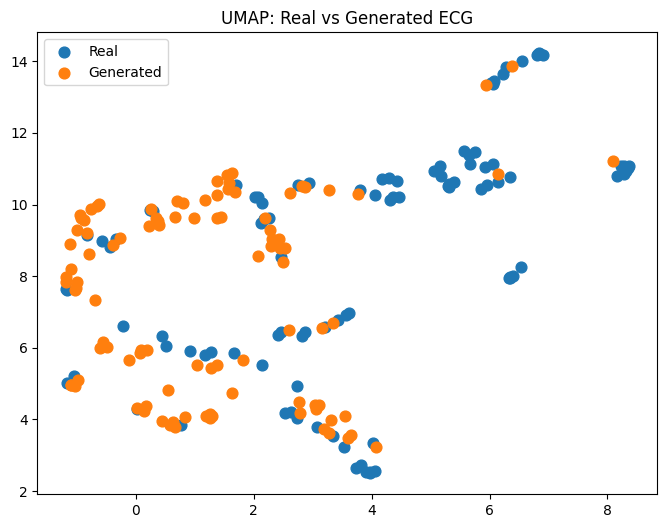

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import pywt
from scipy.signal import resample
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import random

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
real_data_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/datasets/heartbeat/mitbih_train.csv"
generated_folder = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/DDPM1D_Selfcond_maskedCond/random_epoch_samples"

# ------------------------------------------------------------
# 2. LOAD 100 REAL SIGNALS (class 0)
# ------------------------------------------------------------
df = pd.read_csv(real_data_path, header=None)
df = df[df.iloc[:, -1] == 0]       # only class 0
df = df.iloc[:100]                 # first 100

real_signals = df.iloc[:, :-1].values
print("Loaded real ECG signals:", real_signals.shape)

# ------------------------------------------------------------
# 3. LOAD GENERATED SIGNALS (all .npy files)
# ------------------------------------------------------------
def load_generated_samples(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith(".npy")])
    samples = []

    for f in files:
        arr = np.load(os.path.join(folder, f))

        if arr.ndim == 3:
            arr = arr[:, 0, :]   # (10,1,128) → (10,128)

        samples.append(arr)

    samples = np.concatenate(samples, axis=0)
    return samples

generated_signals = load_generated_samples(generated_folder)
print("Loaded generated signals:", generated_signals.shape)

# pick 100 random generated samples
generated_signals = generated_signals[:100]

# ------------------------------------------------------------
# 4. RESAMPLE REAL SIGNALS → 128 length
# ------------------------------------------------------------
gen_len = generated_signals.shape[1]

real_resampled = np.array([resample(sig, gen_len) for sig in real_signals])
print("Resampled real ECG signals:", real_resampled.shape)

# ------------------------------------------------------------
# 5. WAVELET COHERENCE
# ------------------------------------------------------------
def wavelet_coherence(sig1, sig2):
    cwt1, _ = pywt.cwt(sig1, np.arange(1, 32), 'morl')
    cwt2, _ = pywt.cwt(sig2, np.arange(1, 32), 'morl')

    numerator = np.abs(np.mean(cwt1 * np.conj(cwt2)))
    denom = np.sqrt(np.mean(np.abs(cwt1)**2) * np.mean(np.abs(cwt2)**2))
    return numerator / denom

wc_scores = [
    wavelet_coherence(real_resampled[i], generated_signals[i])
    for i in range(100)
]

print("\nWavelet Coherence Score:", np.mean(wc_scores))

# ------------------------------------------------------------
# 6. DISCRIMINATIVE SCORE (SVM)
# ------------------------------------------------------------
X = np.vstack([real_resampled, generated_signals])
y = np.array([0]*100 + [1]*100)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3
)

clf = SVC(kernel='rbf')
clf.fit(X_train, y_train)

disc_score = clf.score(X_test, y_test)
print("Discriminative Score (SVM accuracy):", disc_score)

# ------------------------------------------------------------
# 7. F1 SCORE
# ------------------------------------------------------------
y_pred = clf.predict(X_test)
print("F1 Score:", f1_score(y_test, y_pred))

# ------------------------------------------------------------
# 8. UMAP VISUALIZATION
# ------------------------------------------------------------
reducer = umap.UMAP(n_neighbors=5, min_dist=0.1)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(embedding[:100, 0], embedding[:100, 1], label="Real", s=60)
plt.scatter(embedding[100:, 0], embedding[100:, 1], label="Generated", s=60)
plt.legend()
plt.title("UMAP: Real vs Generated ECG")
plt.show()


Loaded real ECG signals: (100, 187)
Loaded generated signals: (1000, 128)
Resampled real ECG signals: (100, 128)

Wavelet Coherence Score: 0.2576893771716484
Discriminative Score (SVM accuracy): 0.9333333333333333
F1 Score: 0.9166666666666666


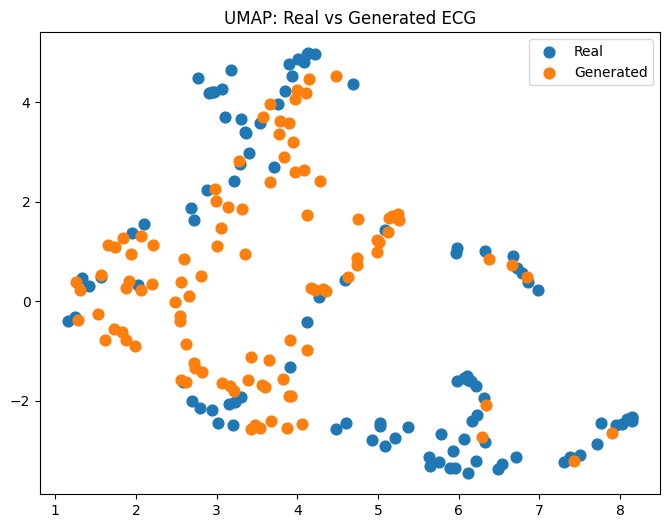

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import pywt
from scipy.signal import resample
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------
real_data_path = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/datasets/heartbeat/mitbih_train.csv"
generated_folder = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/DDPM1D_Selfcond_maskedCond/random_epoch_samples"

# ------------------------------------------------------------
# 2. LOAD REAL DATA (100 samples of class 0)
# ------------------------------------------------------------
df = pd.read_csv(real_data_path, header=None)

# Filter only class 0
df_class0 = df[df.iloc[:, -1] == 0]

real_signals = df_class0.iloc[:100, :-1].values      # (100, 187)
real_labels  = df_class0.iloc[:100, -1].values

print("Loaded real ECG signals:", real_signals.shape)

# ------------------------------------------------------------
# 3. LOAD ALL GENERATED SAMPLES
# ------------------------------------------------------------
def load_generated_samples(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith(".npy")])

    samples = []

    for f in files:
        arr = np.load(os.path.join(folder, f))   # shape (10,128)

        # (N,1,128) -> (N,128)
        if arr.ndim == 3:
            arr = arr[:, 0, :]

        samples.append(arr)

    samples = np.concatenate(samples, axis=0)  # (1000,128)

    return samples

generated_signals = load_generated_samples(generated_folder)
print("Loaded generated signals:", generated_signals.shape)

# ------------------------------------------------------------
# 4. RESAMPLE REAL SIGNALS TO MATCH GENERATED SIGNAL LENGTH (128)
# ------------------------------------------------------------
gen_len = generated_signals.shape[1]

real_resampled = np.array([
    resample(sig, gen_len) for sig in real_signals
])

print("Resampled real ECG signals:", real_resampled.shape)

# ------------------------------------------------------------
# 5. WAVELET COHERENCE
# ------------------------------------------------------------
def wavelet_coherence(sig1, sig2):
    scales = np.arange(1, 32)
    cwt1, _ = pywt.cwt(sig1, scales=scales, wavelet='morl')
    cwt2, _ = pywt.cwt(sig2, scales=scales, wavelet='morl')

    numerator = np.abs(np.mean(cwt1 * np.conj(cwt2)))
    denom = np.sqrt(np.mean(np.abs(cwt1)**2) * np.mean(np.abs(cwt2)**2))

    return numerator / denom

# compute for 100 pairs
wc_scores = [
    wavelet_coherence(real_resampled[i], generated_signals[i])
    for i in range(100)
]

print("\nWavelet Coherence Score:", np.mean(wc_scores))

# ------------------------------------------------------------
# 6. DISCRIMINATIVE SCORE (SVM)
# ------------------------------------------------------------
# take 100 from synthetic too
generated_100 = generated_signals[:100]

X = np.vstack([real_resampled, generated_100])
y = np.array([0]*100 + [1]*100)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3
)

clf = SVC(kernel='rbf')
clf.fit(X_train, y_train)

disc_score = clf.score(X_test, y_test)
print("Discriminative Score (SVM accuracy):", disc_score)

# ------------------------------------------------------------
# 7. F1 SCORE
# ------------------------------------------------------------
y_pred = clf.predict(X_test)
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

# ------------------------------------------------------------
# 8. UMAP VISUALIZATION
# ------------------------------------------------------------
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(embedding[:100, 0], embedding[:100, 1], label="Real", s=60)
plt.scatter(embedding[100:, 0], embedding[100:, 1], label="Generated", s=60)
plt.legend()
plt.title("UMAP: Real vs Generated ECG")
plt.show()


Loaded real signals: (100, 187)
Loaded 1000 generated signals from 100 files. Each length = 128
Selected 100 generated indices. Example mappings (first 10):
  ('gen_epoch_68.npy', 4)
  ('gen_epoch_19.npy', 4)
  ('gen_epoch_10.npy', 5)
  ('gen_epoch_77.npy', 9)
  ('gen_epoch_34.npy', 1)
  ('gen_epoch_31.npy', 0)
  ('gen_epoch_29.npy', 8)
  ('gen_epoch_21.npy', 2)
  ('gen_epoch_77.npy', 4)
  ('gen_epoch_18.npy', 4)
Selected generated signals shape: (100, 128)
real_norm shape: (100, 128) gen_norm shape: (100, 128)
Computing pairwise wavelet coherence matrix... (this can take time)
Mean pairwise coherence (real vs gen), N=100: 0.2442
Coherence matrix stats: mean 0.2442, std 0.1735, min 0.0000, max 0.9548
Per-real mean coherence (first 10): [0.24067414 0.25110608 0.15366149 0.19505101 0.27833202 0.21446928
 0.18720995 0.14367132 0.25969176 0.27875427]
Per-gen  mean coherence (first 10): [0.1915581  0.1938568  0.24626433 0.31300351 0.31142333 0.21562816
 0.19912194 0.29736991 0.24466413 0.28

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


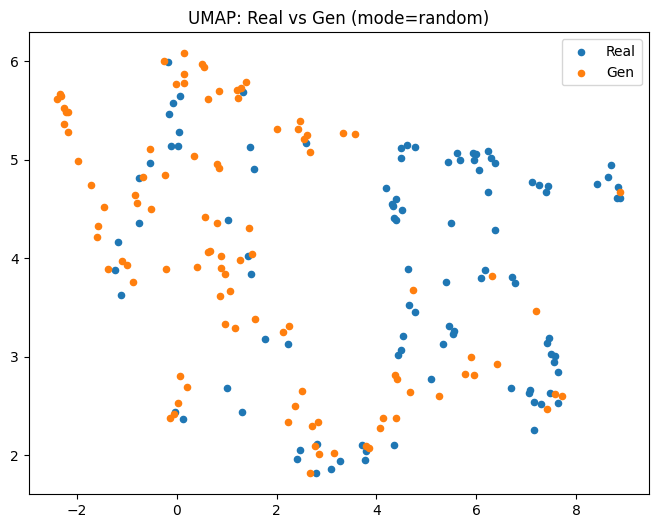


DIAGNOSTICS:
 - total generated pool M = 1000
 - total epoch files = 100
 - selection_mode = random
 - chosen generated filenames (unique): ['gen_epoch_0.npy', 'gen_epoch_10.npy', 'gen_epoch_11.npy', 'gen_epoch_12.npy', 'gen_epoch_15.npy', 'gen_epoch_16.npy', 'gen_epoch_17.npy', 'gen_epoch_18.npy', 'gen_epoch_19.npy', 'gen_epoch_2.npy']
 - If you expected all generated samples to be class 0 please confirm your generation script used that conditioning label.


In [ ]:
import os
import numpy as np
import pandas as pd
import pywt
from scipy.signal import resample
from sklearn.svm import SVC
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt
import random

# -------------------------
# SETTINGS (edit if needed)
# -------------------------
real_csv = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/datasets/heartbeat/mitbih_train.csv"
generated_folder = "/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/DDPM1D_Selfcond_maskedCond/random_epoch_samples"

class_id = 0       # class to evaluate (must match conditioning used during sampling)
N = 100            # number of real & synthetic samples to use
random_seed = 42

# selection_mode:
#   'random'         -> pick N generated samples randomly from all generated pool
#   'single_epoch'   -> pick from a single epoch file (set epoch_to_use)
#   'uniform_epochs' -> sample uniformly across epoch files until N reached
selection_mode = 'random'
epoch_to_use = 82   # used when selection_mode == 'single_epoch'

# -------------------------
# UTIL: wavelet coherence scalar
# -------------------------
def wavelet_coherence_scalar(sig1, sig2, scales=np.arange(1, 32), wavelet='morl'):
    cwt1, _ = pywt.cwt(sig1, scales=scales, wavelet=wavelet)
    cwt2, _ = pywt.cwt(sig2, scales=scales, wavelet=wavelet)
    numerator = np.abs(np.mean(cwt1 * np.conj(cwt2)))
    denom = np.sqrt(np.mean(np.abs(cwt1)**2) * np.mean(np.abs(cwt2)**2))
    return (numerator / denom) if denom != 0 else 0.0

# -------------------------
# 1) Load real class samples (N)
# -------------------------
df = pd.read_csv(real_csv, header=None)
df_class = df[df.iloc[:, -1] == class_id]
if len(df_class) < N:
    raise ValueError(f"Not enough real samples for class {class_id}: found {len(df_class)} < {N}")

# choose first N (or you could random.sample)
real_signals = df_class.iloc[:N, :-1].values.astype(float)
print("Loaded real signals:", real_signals.shape)

# -------------------------
# 2) Load generated pool (all .npy), keep track of filenames
# -------------------------
gen_files = sorted([f for f in os.listdir(generated_folder) if f.endswith(".npy")])
if len(gen_files) == 0:
    raise ValueError("No generated .npy files found in folder: " + generated_folder)

# load all arrays (concatenate). Keep mapping from global index -> (filename, local_index)
generated_all = []
index_map = []  # list of tuples (filename, local_idx)
for fname in gen_files:
    arr = np.load(os.path.join(generated_folder, fname))
    # shape may be (10,128) or (10,1,128) or (B,128)
    if arr.ndim == 3:
        arr = arr[:, 0, :]
    arr = arr.astype(float)
    for local_idx in range(arr.shape[0]):
        generated_all.append(arr[local_idx])
        index_map.append((fname, local_idx))
generated_all = np.stack(generated_all, axis=0)  # (M, L_gen)
M, L_gen = generated_all.shape
print(f"Loaded {M} generated signals from {len(gen_files)} files. Each length = {L_gen}")

# -------------------------
# 3) Choose N generated samples (selection_mode)
# -------------------------
random.seed(random_seed)
np.random.seed(random_seed)

if selection_mode == 'random':
    if M < N:
        raise ValueError(f"Not enough generated samples ({M}) to select {N}")
    chosen_idxs = random.sample(range(M), N)

elif selection_mode == 'single_epoch':
    # find file name for epoch
    target_fname = None
    # look for file that contains "epoch_{epoch_to_use}" (flexible)
    target_token = f"epoch_{epoch_to_use}"
    for f in gen_files:
        if target_token in f:
            target_fname = f
            break
    if target_fname is None:
        raise ValueError(f"No generated file found for epoch token {target_token}")
    # load that file and pick up to N (or error)
    arr = np.load(os.path.join(generated_folder, target_fname))
    if arr.ndim == 3:
        arr = arr[:, 0, :]
    if arr.shape[0] < N:
        raise ValueError(f"File {target_fname} contains only {arr.shape[0]} samples < {N}")
    # find global indices that map to this file
    chosen_idxs = [i for i,(fname,local) in enumerate(index_map) if fname == target_fname]
    chosen_idxs = chosen_idxs[:N]

elif selection_mode == 'uniform_epochs':
    # sample evenly from each epoch file until N reached
    chosen_idxs = []
    per_file = max(1, N // len(gen_files))
    for fname in gen_files:
        arr = np.load(os.path.join(generated_folder, fname))
        if arr.ndim == 3:
            arr = arr[:,0,:]
        take = min(per_file, arr.shape[0])
        # find global indices
        global_indices = [i for i,(fn,li) in enumerate(index_map) if fn == fname]
        chosen_idxs.extend(global_indices[:take])
    # If still short, randomly add more
    if len(chosen_idxs) < N:
        remaining = list(set(range(M)) - set(chosen_idxs))
        needed = N - len(chosen_idxs)
        chosen_idxs.extend(random.sample(remaining, needed))
    chosen_idxs = chosen_idxs[:N]

else:
    raise ValueError("Unknown selection_mode: " + selection_mode)

# show chosen mapping
chosen_map = [index_map[i] for i in chosen_idxs]
print(f"Selected {len(chosen_idxs)} generated indices. Example mappings (first 10):")
for item in chosen_map[:10]:
    print(" ", item)

gen_selected = generated_all[chosen_idxs]  # (N, L_gen)
print("Selected generated signals shape:", gen_selected.shape)

# -------------------------
# 4) Resample real signals -> gen length and normalize (zero mean unit std)
# -------------------------
real_resampled = np.array([resample(sig, L_gen) for sig in real_signals])

def normalize_sig(x):
    x = np.array(x, dtype=float)
    m = x.mean()
    s = x.std()
    return (x - m) / s if s > 0 else (x - m)

real_norm = np.array([normalize_sig(s) for s in real_resampled])
gen_norm  = np.array([normalize_sig(s) for s in gen_selected])

print("real_norm shape:", real_norm.shape, "gen_norm shape:", gen_norm.shape)

# -------------------------
# 5) Pairwise coherence matrix and diagnostics
# -------------------------
N_check = min(N, real_norm.shape[0], gen_norm.shape[0])
coh = np.zeros((N_check, N_check), dtype=float)
print("Computing pairwise wavelet coherence matrix... (this can take time)")

for i in range(N_check):
    for j in range(N_check):
        coh[i,j] = wavelet_coherence_scalar(real_norm[i], gen_norm[j])

mean_coherence = coh.mean()
print(f"Mean pairwise coherence (real vs gen), N={N_check}: {mean_coherence:.4f}")
print("Coherence matrix stats: mean {:.4f}, std {:.4f}, min {:.4f}, max {:.4f}".format(coh.mean(), coh.std(), coh.min(), coh.max()))

# per-real and per-gen means
per_real_mean = coh.mean(axis=1)
per_gen_mean  = coh.mean(axis=0)
print("Per-real mean coherence (first 10):", per_real_mean[:10])
print("Per-gen  mean coherence (first 10):", per_gen_mean[:10])

# -------------------------
# 6) SVM discriminative test (uses same selected 100 vs 100)
# -------------------------
X = np.vstack([real_norm[:N_check], gen_norm[:N_check]])
y = np.array([0]*N_check + [1]*N_check)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=random_seed)

clf = SVC(kernel='rbf')
clf.fit(X_train, y_train)
acc = clf.score(X_test, y_test)
f1 = f1_score(y_test, clf.predict(X_test))
print(f"SVM accuracy: {acc:.4f}, F1: {f1:.4f}")

# -------------------------
# 7) UMAP for visualization
# -------------------------
reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, random_state=random_seed)
embedding = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(embedding[:N_check,0], embedding[:N_check,1], label='Real', s=20)
plt.scatter(embedding[N_check:,0], embedding[N_check:,1], label='Gen', s=20)
plt.legend()
plt.title(f"UMAP: Real vs Gen (mode={selection_mode})")
plt.show()

# -------------------------
# 8) Diagnostics to check conditioning assumptions
# -------------------------
print("\nDIAGNOSTICS:")
print(" - total generated pool M =", M)
print(" - total epoch files =", len(gen_files))
print(" - selection_mode =", selection_mode)
if selection_mode == 'single_epoch':
    print(" - epoch_to_use =", epoch_to_use)
print(" - chosen generated filenames (unique):", sorted(set([m[0] for m in chosen_map]))[:10])
print(" - If you expected all generated samples to be class", class_id, "please confirm your generation script used that conditioning label.")


In [ ]:
!git clone https://github.com/Deepali122003/biodiffusion_project.git

Cloning into 'biodiffusion_project'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
%pwd


'/content'

In [ ]:
%cd /content/drive/MyDrive/NN_RESEARCH


/content/drive/MyDrive/NN_RESEARCH


In [ ]:
!mv /content/NN_RESEARCH ./NN_RESEARCH


^C


In [ ]:
!find /content/drive/MyDrive -maxdepth 3 -type d -name ".git"


/content/drive/MyDrive/NN_RESEARCH/biodiffusion/.git


In [ ]:
!cd /content/drive/MyDrive/NN_RESEARCH/biodiffusion/

In [ ]:
!ls /content/drive/MyDrive/NN_RESEARCH/


 biodiffusion  'kaggle (1) (1).json'   models	     runs
 checkpoint    'kaggle (1) (2).json'   NN_RESEARCH   wandb
 datasets      'kaggle (1).json'       results


In [ ]:
!ls /content/drive/MyDrive/NN_RESEARCH/biodiffusion/.git


branches  description  hooks  info  objects	 refs
config	  HEAD	       index  logs  packed-refs


In [ ]:
!rm -rf /content/drive/MyDrive/NN_RESEARCH/biodiffusion/.git


In [ ]:
!git clone https://github.com/Deepali122003/biodiffusion_project.git


Cloning into 'biodiffusion_project'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
!cp -r /content/drive/MyDrive/NN_RESEARCH/biodiffusion/* biodiffusion_project/


cp: error reading '/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional/epoch_2.pt': Software caused connection abort
cp: failed to close '/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional/epoch_2.pt': Transport endpoint is not connected
cp: cannot stat '/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional/epoch_3.pt': Transport endpoint is not connected
cp: cannot stat '/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional/epoch_4.pt': Transport endpoint is not connected
cp: cannot stat '/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional/epoch_5.pt': Transport endpoint is not connected
cp: cannot stat '/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_conditional/epoch_6.pt': Transport endpoint is not connected
cp: cannot stat '/content/drive/MyDrive/NN_RESEARCH/biodiffusion/results/checkpoints_ddpm_c